## House Prices 
**Autor:** Valérie RUSSO

**Kaggle Competition:** House Prices - Advanced Regression Techniques

*This notebook explores several regression models and ensemble techniques to predict house prices.*

## Objective
Predict house prices from structured data using a robust and generalizable machine learning pipeline.

## Results
- **Final score (public leaderboard): 0.11908 (RMSE on log(SalePrice))**
- Competitive ranking on the leaderbord competition (top 5 % in April 2026)

## Approach
- Data Cleaning and Feature engineering based on domain knowledge and data-driven analysis
(interaction features, skewness correction, correlation analysis, data visualisation)  
- Careful handling of missing values and ordinal encoding  
- Reduction of overfitting by removing noisy and redundant features  
- Outlier filtering tested then removed to improve generalization  
- Cross-validation with Out-of-Fold (OOF) predictions  
- Comparison of multiple models:
  - Linear models (Ridge, ElasticNet)
  - Tree-based models (RandomForest, LightGBM, XGBoost, CatBoost)  
- Hyperparameter tuning :
    - RandomizedSearchCV for all models except XGBoost
    - Custom OOF cross-validation with early stopping for XGBoost  
- Ensemble learning comparison:
  - Blending (optimized weights on OOF predictions)  
  - Stacking (meta-models: Ridge, ElasticNet and RandomForest)

  ## Key Takeaways
  
  - Controlling overfitting is as important as improving performance  
  - Simpler and cleaner feature sets improve generalization  
  - Blending proved more robust than stacking in this case


# 1. Data Loading

In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
from sklearn import set_config
set_config(transform_output="pandas")

In [3]:
train_val = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
train_val.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
X_test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
X_test.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [5]:
modele = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv")
modele.head(5)

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [6]:
X_train_val=train_val.drop("SalePrice", axis=1)

In [7]:
# Transformation of the Id column into index
X_train_val.set_index("Id", inplace=True)
X_test.set_index("Id", inplace=True)

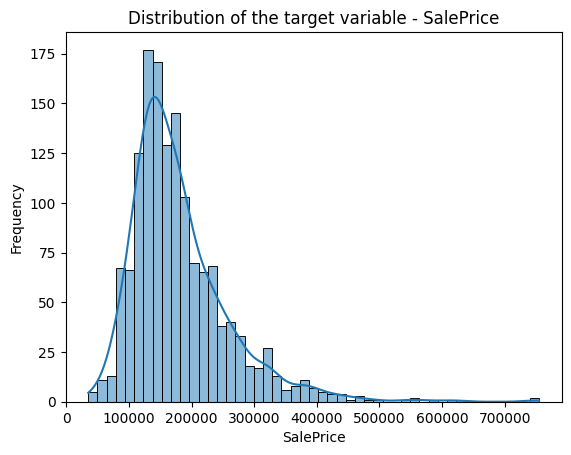

In [8]:
y_train_val = train_val.set_index("Id")["SalePrice"]
y_train_val.mean()

# Distribution of the target variable
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(y_train_val, kde=True)
plt.title("Distribution of the target variable - SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

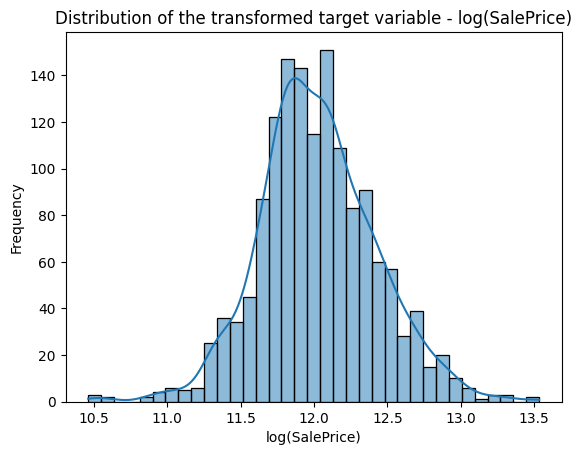

In [9]:
# Transformation of the target variable with log to reduce the effect of extreme values
y_train_val_log = np.log1p(y_train_val)

# Distribution of the transformed target variable
sns.histplot(y_train_val_log, kde=True)
plt.title("Distribution of the transformed target variable - log(SalePrice)")
plt.xlabel("log(SalePrice)")
plt.ylabel("Frequency")
plt.show()

In [10]:
X_train_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

# 2. Data split used for initial baseline model (no cross validation)
Cross validation is done later for more robust evaluation.

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X_train_val, y_train_val_log,  # garde l’alignement index
    test_size=0.2,
    random_state=42
)

# 3. Data cleaning and Feature engineering

In [12]:
# MSSubClass: The building class is a categorical variable, not numeric from data description. It needs to be converted to a categorical variable.
# Same for OverallQual and OverallCond, which are ratings from 1 to 10,
# but they represent categories of quality and condition, not continuous numeric values.
X_train["MSSubClass cat"] = X_train["MSSubClass"].astype(str)
X_val["MSSubClass cat"] = X_val["MSSubClass"].astype(str)
X_test["MSSubClass cat"] = X_test["MSSubClass"].astype(str)



In [13]:
# Checking the percentage of missing values for numerical features
missing_values = X_train.isnull().sum()
missing_percentage = (missing_values / len(X_train)) * 100
print("Percentage of missing values by column:")
print(missing_percentage[missing_percentage > 0])

Percentage of missing values by column:
LotFrontage     18.578767
Alley           93.664384
MasVnrType      58.476027
MasVnrArea       0.513699
BsmtQual         2.397260
BsmtCond         2.397260
BsmtExposure     2.397260
BsmtFinType1     2.397260
BsmtFinType2     2.397260
Electrical       0.085616
FireplaceQu     46.832192
GarageType       5.479452
GarageYrBlt      5.479452
GarageFinish     5.479452
GarageQual       5.479452
GarageCond       5.479452
PoolQC          99.486301
Fence           80.051370
MiscFeature     96.061644
dtype: float64


In [14]:
# Given data description, the following features are declared as categorical whereas they should be ordinal features 
# because they can be mapped to numerical values based on their categories:
ordinal_features = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
                    "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC",
                    "BsmtFinType1","BsmtFinType2", "Functional", "GarageFinish",
                    "PavedDrive", "LandSlope", "BsmtExposure", "OverallQual", "OverallCond"]

In [15]:
# Checking the percentage of missing values for ordinal features
for col in ordinal_features:
    X_train[col] = X_train[col].fillna("NA")
    X_val[col] = X_val[col].fillna("NA")
    X_test[col] = X_test[col].fillna("NA")

In [16]:
# Affiche toutes les colonnes numériques de X_train
numerical_features=X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_features

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [17]:
# Looking into data description, transformation of ordinal data into numerical data is needed when there is an order in the categories.
# For example, for the feature "ExterQual" (Exterior material quality), the categories are "Ex", "Gd", "TA", "Fa", and "Po", which represent different levels of quality. We can map these categories to numerical values based on their order of quality, such as Ex=5, Gd=4, TA=3, Fa=2, Po=1. 
# This way, we can capture the ordinal relationship between the categories and use it in our model.
# Manual mapping for ordinal features is necessary to preserve the order of categories and ensure that the model can learn from the ordinal relationships in the data.
# Ordinal data will be int data type
quality_mapping = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0}
X_train["ExterQual num"] = X_train["ExterQual"].map(quality_mapping)
X_val["ExterQual num"] = X_val["ExterQual"].map(quality_mapping)
X_test["ExterQual num"] = X_test["ExterQual"].map(quality_mapping)

X_train["ExterCond num"] = X_train["ExterCond"].map(quality_mapping)
X_val["ExterCond num"] = X_val["ExterCond"].map(quality_mapping)
X_test["ExterCond num"] = X_test["ExterCond"].map(quality_mapping)

X_train["BsmtQual num"] = X_train["BsmtQual"].map(quality_mapping)
X_val["BsmtQual num"] = X_val["BsmtQual"].map(quality_mapping)
X_test["BsmtQual num"] = X_test["BsmtQual"].map(quality_mapping)

X_train["BsmtCond num"] = X_train["BsmtCond"].map(quality_mapping)
X_val["BsmtCond num"] = X_val["BsmtCond"].map(quality_mapping)
X_test["BsmtCond num"] = X_test["BsmtCond"].map(quality_mapping)

X_train["HeatingQC num"] = X_train["HeatingQC"].map(quality_mapping)
X_val["HeatingQC num"] = X_val["HeatingQC"].map(quality_mapping)
X_test["HeatingQC num"] = X_test["HeatingQC"].map(quality_mapping)

X_train["KitchenQual num"] = X_train["KitchenQual"].map(quality_mapping)
X_val["KitchenQual num"] = X_val["KitchenQual"].map(quality_mapping)
X_test["KitchenQual num"] = X_test["KitchenQual"].map(quality_mapping)

X_train["FireplaceQu num"] = X_train["FireplaceQu"].map(quality_mapping)
X_val["FireplaceQu num"] = X_val["FireplaceQu"].map(quality_mapping)
X_test["FireplaceQu num"] = X_test["FireplaceQu"].map(quality_mapping)

X_train["GarageQual num"] = X_train["GarageQual"].map(quality_mapping)
X_val["GarageQual num"] = X_val["GarageQual"].map(quality_mapping)
X_test["GarageQual num"] = X_test["GarageQual"].map(quality_mapping)

X_train["GarageCond num"] = X_train["GarageCond"].map(quality_mapping)
X_val["GarageCond num"] = X_val["GarageCond"].map(quality_mapping)
X_test["GarageCond num"] = X_test["GarageCond"].map(quality_mapping)

X_train["PoolQC num"] = X_train["PoolQC"].map(quality_mapping)
X_val["PoolQC num"] = X_val["PoolQC"].map(quality_mapping)
X_test["PoolQC num"] = X_test["PoolQC"].map(quality_mapping)

# Other mapping for features with different categories
exposure_mapping = {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "NA": 0}
X_train["BsmtExposure num"] = X_train["BsmtExposure"].map(exposure_mapping)
X_val["BsmtExposure num"] = X_val["BsmtExposure"].map(exposure_mapping)
X_test["BsmtExposure num"] = X_test["BsmtExposure"].map(exposure_mapping)

# Other mapping for features with different categories
bsmtf_mapping = {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "NA": 0}
X_train["BsmtFinType1 num"] = X_train["BsmtFinType1"].map(bsmtf_mapping)
X_val["BsmtFinType1 num"] = X_val["BsmtFinType1"].map(bsmtf_mapping)
X_test["BsmtFinType1 num"] = X_test["BsmtFinType1"].map(bsmtf_mapping)

X_train["BsmtFinType2 num"] = X_train["BsmtFinType2"].map(bsmtf_mapping)
X_val["BsmtFinType2 num"] = X_val["BsmtFinType2"].map(bsmtf_mapping)
X_test["BsmtFinType2 num"] = X_test["BsmtFinType2"].map(bsmtf_mapping)

# Other mapping for Functional feature
functional_mapping = {"Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4, "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0}
X_train["Functional num"] = X_train["Functional"].map(functional_mapping)
X_val["Functional num"] = X_val["Functional"].map(functional_mapping)
X_test["Functional num"] = X_test["Functional"].map(functional_mapping)

# Other mapping for GarageFinish feature
garagefinish_mapping = {"Fin": 3, "RFn": 2, "Unf": 1, "NA": 0}
X_train["GarageFinish num"] = X_train["GarageFinish"].map(garagefinish_mapping)
X_val["GarageFinish num"] = X_val["GarageFinish"].map(garagefinish_mapping)
X_test["GarageFinish num"] = X_test["GarageFinish"].map(garagefinish_mapping)

# Other mapping for PavedDrive feature
paveddrive_mapping = {"Y": 3, "P": 2, "N": 1}
X_train["PavedDrive num"] = X_train["PavedDrive"].map(paveddrive_mapping)
X_val["PavedDrive num"] = X_val["PavedDrive"].map(paveddrive_mapping)
X_test["PavedDrive num"] = X_test["PavedDrive"].map(paveddrive_mapping)

# Other mapping for LandSlope feature
landslope_mapping = {"Gtl": 3, "Mod": 2, "Sev": 1}
X_train["LandSlope num"] = X_train["LandSlope"].map(landslope_mapping)
X_val["LandSlope num"] = X_val["LandSlope"].map(landslope_mapping)
X_test["LandSlope num"] = X_test["LandSlope"].map(landslope_mapping)

#mapping for OverallQual and OverallCond features
overall_mapping = {10: 10, 9: 9, 8: 8, 7: 7, 6: 6, 5: 5, 4: 4, 3: 3, 2: 2, 1: 1, 0: 0}
X_train["OverallQual num"] = X_train["OverallQual"].map(overall_mapping)
X_val["OverallQual num"] = X_val["OverallQual"].map(overall_mapping)
X_test["OverallQual num"] = X_test["OverallQual"].map(overall_mapping)

X_train["OverallCond num"] = X_train["OverallCond"].map(overall_mapping)
X_val["OverallCond num"] = X_val["OverallCond"].map(overall_mapping)
X_test["OverallCond num"] = X_test["OverallCond"].map(overall_mapping)

In [18]:
#Creation of new features 
# garage area for each car avoiding division by zero
X_train["GarageArea_per_car"] = X_train.apply(lambda row: row["GarageArea"] / row["GarageCars"] if row["GarageCars"] > 0 else 0, axis=1)
X_val["GarageArea_per_car"] = X_val.apply(lambda row: row["GarageArea"] / row["GarageCars"] if row["GarageCars"] > 0 else 0, axis=1)
X_test["GarageArea_per_car"] = X_test.apply(lambda row: row["GarageArea"] / row["GarageCars"] if row["GarageCars"] > 0 else 0, axis=1)


In [19]:
# Total living area (basement + floors)
X_train["TotalSF"] = X_train["TotalBsmtSF"] + X_train["1stFlrSF"] + X_train["2ndFlrSF"]
X_val["TotalSF"] = X_val["TotalBsmtSF"] + X_val["1stFlrSF"] + X_val["2ndFlrSF"]
X_test["TotalSF"] = X_test["TotalBsmtSF"] + X_test["1stFlrSF"] + X_test["2ndFlrSF"]
# Age of the house
X_train["HouseAge"] = X_train["YrSold"] - X_train["YearBuilt"]
X_val["HouseAge"] = X_val["YrSold"] - X_val["YearBuilt"]
X_test["HouseAge"] = X_test["YrSold"] - X_test["YearBuilt"]
# Total number of bathrooms
X_train["TotalBath"] = X_train["FullBath"] + (0.5 * X_train["HalfBath"])+ X_train["BsmtFullBath"] + (0.5 * X_train["BsmtHalfBath"])
X_val["TotalBath"] = X_val["FullBath"] + (0.5 * X_val["HalfBath"])+ X_val["BsmtFullBath"] + (0.5 * X_val["BsmtHalfBath"])
X_test["TotalBath"] = X_test["FullBath"] + (0.5 * X_test["HalfBath"])+ X_test["BsmtFullBath"] + (0.5 * X_test["BsmtHalfBath"])

# Overall quality weighted by house age
X_train["OverallQualAge"] = X_train["OverallQual num"] / (X_train["HouseAge"] + 1)
X_val["OverallQualAge"] = X_val["OverallQual num"] / (X_val["HouseAge"] + 1)
X_test["OverallQualAge"] = X_test["OverallQual num"] / (X_test["HouseAge"] + 1)
# Quality * area
X_train["QualSF"] = X_train["OverallQual num"] * X_train["TotalSF"]
X_val["QualSF"] = X_val["OverallQual num"] * X_val["TotalSF"]
X_test["QualSF"] = X_test["OverallQual num"] * X_test["TotalSF"]
# Age after remodeling
X_train["AgeAfterRemod"] = X_train["YrSold"] - X_train["YearRemodAdd"]
X_val["AgeAfterRemod"] = X_val["YrSold"] - X_val["YearRemodAdd"]
X_test["AgeAfterRemod"] = X_test["YrSold"] - X_test["YearRemodAdd"]


## Deletion of features after tranformation

In [20]:
# Delete the original categorical feature "MSSubClass" after transformation
X_train.drop(columns="MSSubClass", inplace=True)
X_val.drop(columns="MSSubClass", inplace=True)
X_test.drop(columns="MSSubClass", inplace=True)

In [21]:
#update of ordinal features list after transformation
wrong_categorical_features_to_drop = ordinal_features
# deletion of the original ordinal features after transformation
X_train.drop(columns=wrong_categorical_features_to_drop, inplace=True)
X_val.drop(columns=wrong_categorical_features_to_drop, inplace=True)
X_test.drop(columns=wrong_categorical_features_to_drop, inplace=True)
ordinal_features = [feature + " num" for feature in ordinal_features]
ordinal_features

['ExterQual num',
 'ExterCond num',
 'BsmtQual num',
 'BsmtCond num',
 'HeatingQC num',
 'KitchenQual num',
 'FireplaceQu num',
 'GarageQual num',
 'GarageCond num',
 'PoolQC num',
 'BsmtFinType1 num',
 'BsmtFinType2 num',
 'Functional num',
 'GarageFinish num',
 'PavedDrive num',
 'LandSlope num',
 'BsmtExposure num',
 'OverallQual num',
 'OverallCond num']

In [22]:
# Deletion of the partial features used to create new features to avoid multicollinearity issues
multicolinear_features_to_drop = ["GarageArea", "GarageCars", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "YearBuilt", "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath", "LotArea", "HouseAge", "TotalSF"]
X_train.drop(columns=multicolinear_features_to_drop, inplace=True)
X_val.drop(columns=multicolinear_features_to_drop, inplace=True)
X_test.drop(columns=multicolinear_features_to_drop, inplace=True)

In [23]:
#update of the list of numerical features after transformation
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
#update of the list of categorical features after transformation
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

In [24]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 255 to 1127
Data columns (total 73 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MSZoning            1168 non-null   object 
 1   LotFrontage         951 non-null    float64
 2   Street              1168 non-null   object 
 3   Alley               74 non-null     object 
 4   LotShape            1168 non-null   object 
 5   LandContour         1168 non-null   object 
 6   Utilities           1168 non-null   object 
 7   LotConfig           1168 non-null   object 
 8   Neighborhood        1168 non-null   object 
 9   Condition1          1168 non-null   object 
 10  Condition2          1168 non-null   object 
 11  BldgType            1168 non-null   object 
 12  HouseStyle          1168 non-null   object 
 13  YearRemodAdd        1168 non-null   int64  
 14  RoofStyle           1168 non-null   object 
 15  RoofMatl            1168 non-null   object 
 16  Exterior1

In [25]:
#number of different values for each  feature
for col in X_train.columns:
    num_unique = X_train[col].nunique()
    if num_unique <=1:
        print(f"{col}: {num_unique} unique values")
    else:
        print(f"More than 1 value: {col}: {num_unique} unique values, {X_train[col].dtype}")

More than 1 value: MSZoning: 5 unique values, object
More than 1 value: LotFrontage: 107 unique values, float64
More than 1 value: Street: 2 unique values, object
More than 1 value: Alley: 2 unique values, object
More than 1 value: LotShape: 4 unique values, object
More than 1 value: LandContour: 4 unique values, object
More than 1 value: Utilities: 2 unique values, object
More than 1 value: LotConfig: 5 unique values, object
More than 1 value: Neighborhood: 25 unique values, object
More than 1 value: Condition1: 9 unique values, object
More than 1 value: Condition2: 8 unique values, object
More than 1 value: BldgType: 5 unique values, object
More than 1 value: HouseStyle: 8 unique values, object
More than 1 value: YearRemodAdd: 61 unique values, int64
More than 1 value: RoofStyle: 6 unique values, object
More than 1 value: RoofMatl: 7 unique values, object
More than 1 value: Exterior1st: 15 unique values, object
More than 1 value: Exterior2nd: 16 unique values, object
More than 1 valu

In [26]:
# autotmatic test to check in categorical features if there are low variance features (one category is dominant) 
# or high missing features (most values are missing)
threshold_unique = 0.99
threshold_missing = 0.8
low_variance_cat_cols = []
high_missing_cols = []
for col in X_train.select_dtypes(include=["object", "string"]).columns:
    top_freq = X_train[col].value_counts(normalize=True).iloc[0]
    if top_freq > threshold_unique:
        low_variance_cat_cols.append(col)
    if X_train[col].isnull().mean() > threshold_missing:
        high_missing_cols.append(col)
print("Low variance categorical columns to be deleted:", low_variance_cat_cols)
print("High missing categorical columns to be deleted:", high_missing_cols)


Low variance categorical columns to be deleted: ['Street', 'Utilities', 'Condition2']
High missing categorical columns to be deleted: ['Alley', 'Fence', 'MiscFeature']


In [27]:
# deletion of the Low variance categorical columns and high missing categorical columns
X_train.drop(columns=low_variance_cat_cols + high_missing_cols, inplace=True)
X_val.drop(columns=low_variance_cat_cols + high_missing_cols, inplace=True)
X_test.drop(columns=low_variance_cat_cols + high_missing_cols, inplace=True)

In [28]:
#categorical features without ordinal features :
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
categorical_features

['MSZoning',
 'LotShape',
 'LandContour',
 'LotConfig',
 'Neighborhood',
 'Condition1',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'Foundation',
 'Heating',
 'CentralAir',
 'Electrical',
 'GarageType',
 'SaleType',
 'SaleCondition',
 'MSSubClass cat']

In [29]:
# Correlation values for numerical features and ordinal features with the target variable
cols_to_include = list(numerical_features) + ["SalePrice"]
cols_to_include


['LotFrontage',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'LowQualFinSF',
 'GrLivArea',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'ExterQual num',
 'ExterCond num',
 'BsmtQual num',
 'BsmtCond num',
 'HeatingQC num',
 'KitchenQual num',
 'FireplaceQu num',
 'GarageQual num',
 'GarageCond num',
 'PoolQC num',
 'BsmtExposure num',
 'BsmtFinType1 num',
 'BsmtFinType2 num',
 'Functional num',
 'GarageFinish num',
 'PavedDrive num',
 'LandSlope num',
 'OverallQual num',
 'OverallCond num',
 'GarageArea_per_car',
 'TotalBath',
 'OverallQualAge',
 'QualSF',
 'AgeAfterRemod',
 'SalePrice']

In [30]:
df_corr = (
    X_train
    .assign(SalePrice=y_train_log.values)[cols_to_include]
)
corr = df_corr.corr()["SalePrice"].sort_values(ascending=False)

print(corr.head(35))

SalePrice             1.000000
OverallQual num       0.807946
QualSF                0.807746
GrLivArea             0.689012
KitchenQual num       0.667939
ExterQual num         0.660159
TotalBath             0.659371
BsmtQual num          0.622365
GarageFinish num      0.607353
YearRemodAdd          0.562152
FireplaceQu num       0.541509
GarageYrBlt           0.530321
TotRmsAbvGrd          0.520082
HeatingQC num         0.484609
Fireplaces            0.481761
OverallQualAge        0.468143
MasVnrArea            0.422218
GarageQual num        0.376042
GarageCond num        0.366829
BsmtExposure num      0.357203
BsmtFinSF1            0.340878
WoodDeckSF            0.340702
LotFrontage           0.334227
BsmtFinType1 num      0.313494
OpenPorchSF           0.305512
PavedDrive num        0.297730
BsmtCond num          0.283268
BsmtUnfSF             0.235227
GarageArea_per_car    0.216417
BedroomAbvGr          0.193340
Functional num        0.145151
ScreenPorch           0.123040
PoolQC n

In [31]:
numerical_top_features = corr[abs(corr)>0.2].index.drop("SalePrice")
numerical_top_features

Index(['OverallQual num', 'QualSF', 'GrLivArea', 'KitchenQual num',
       'ExterQual num', 'TotalBath', 'BsmtQual num', 'GarageFinish num',
       'YearRemodAdd', 'FireplaceQu num', 'GarageYrBlt', 'TotRmsAbvGrd',
       'HeatingQC num', 'Fireplaces', 'OverallQualAge', 'MasVnrArea',
       'GarageQual num', 'GarageCond num', 'BsmtExposure num', 'BsmtFinSF1',
       'WoodDeckSF', 'LotFrontage', 'BsmtFinType1 num', 'OpenPorchSF',
       'PavedDrive num', 'BsmtCond num', 'BsmtUnfSF', 'GarageArea_per_car',
       'AgeAfterRemod'],
      dtype='object')

In [32]:
continuous_numerical_features = [col for col in numerical_top_features if X_train[col].nunique() > 20]

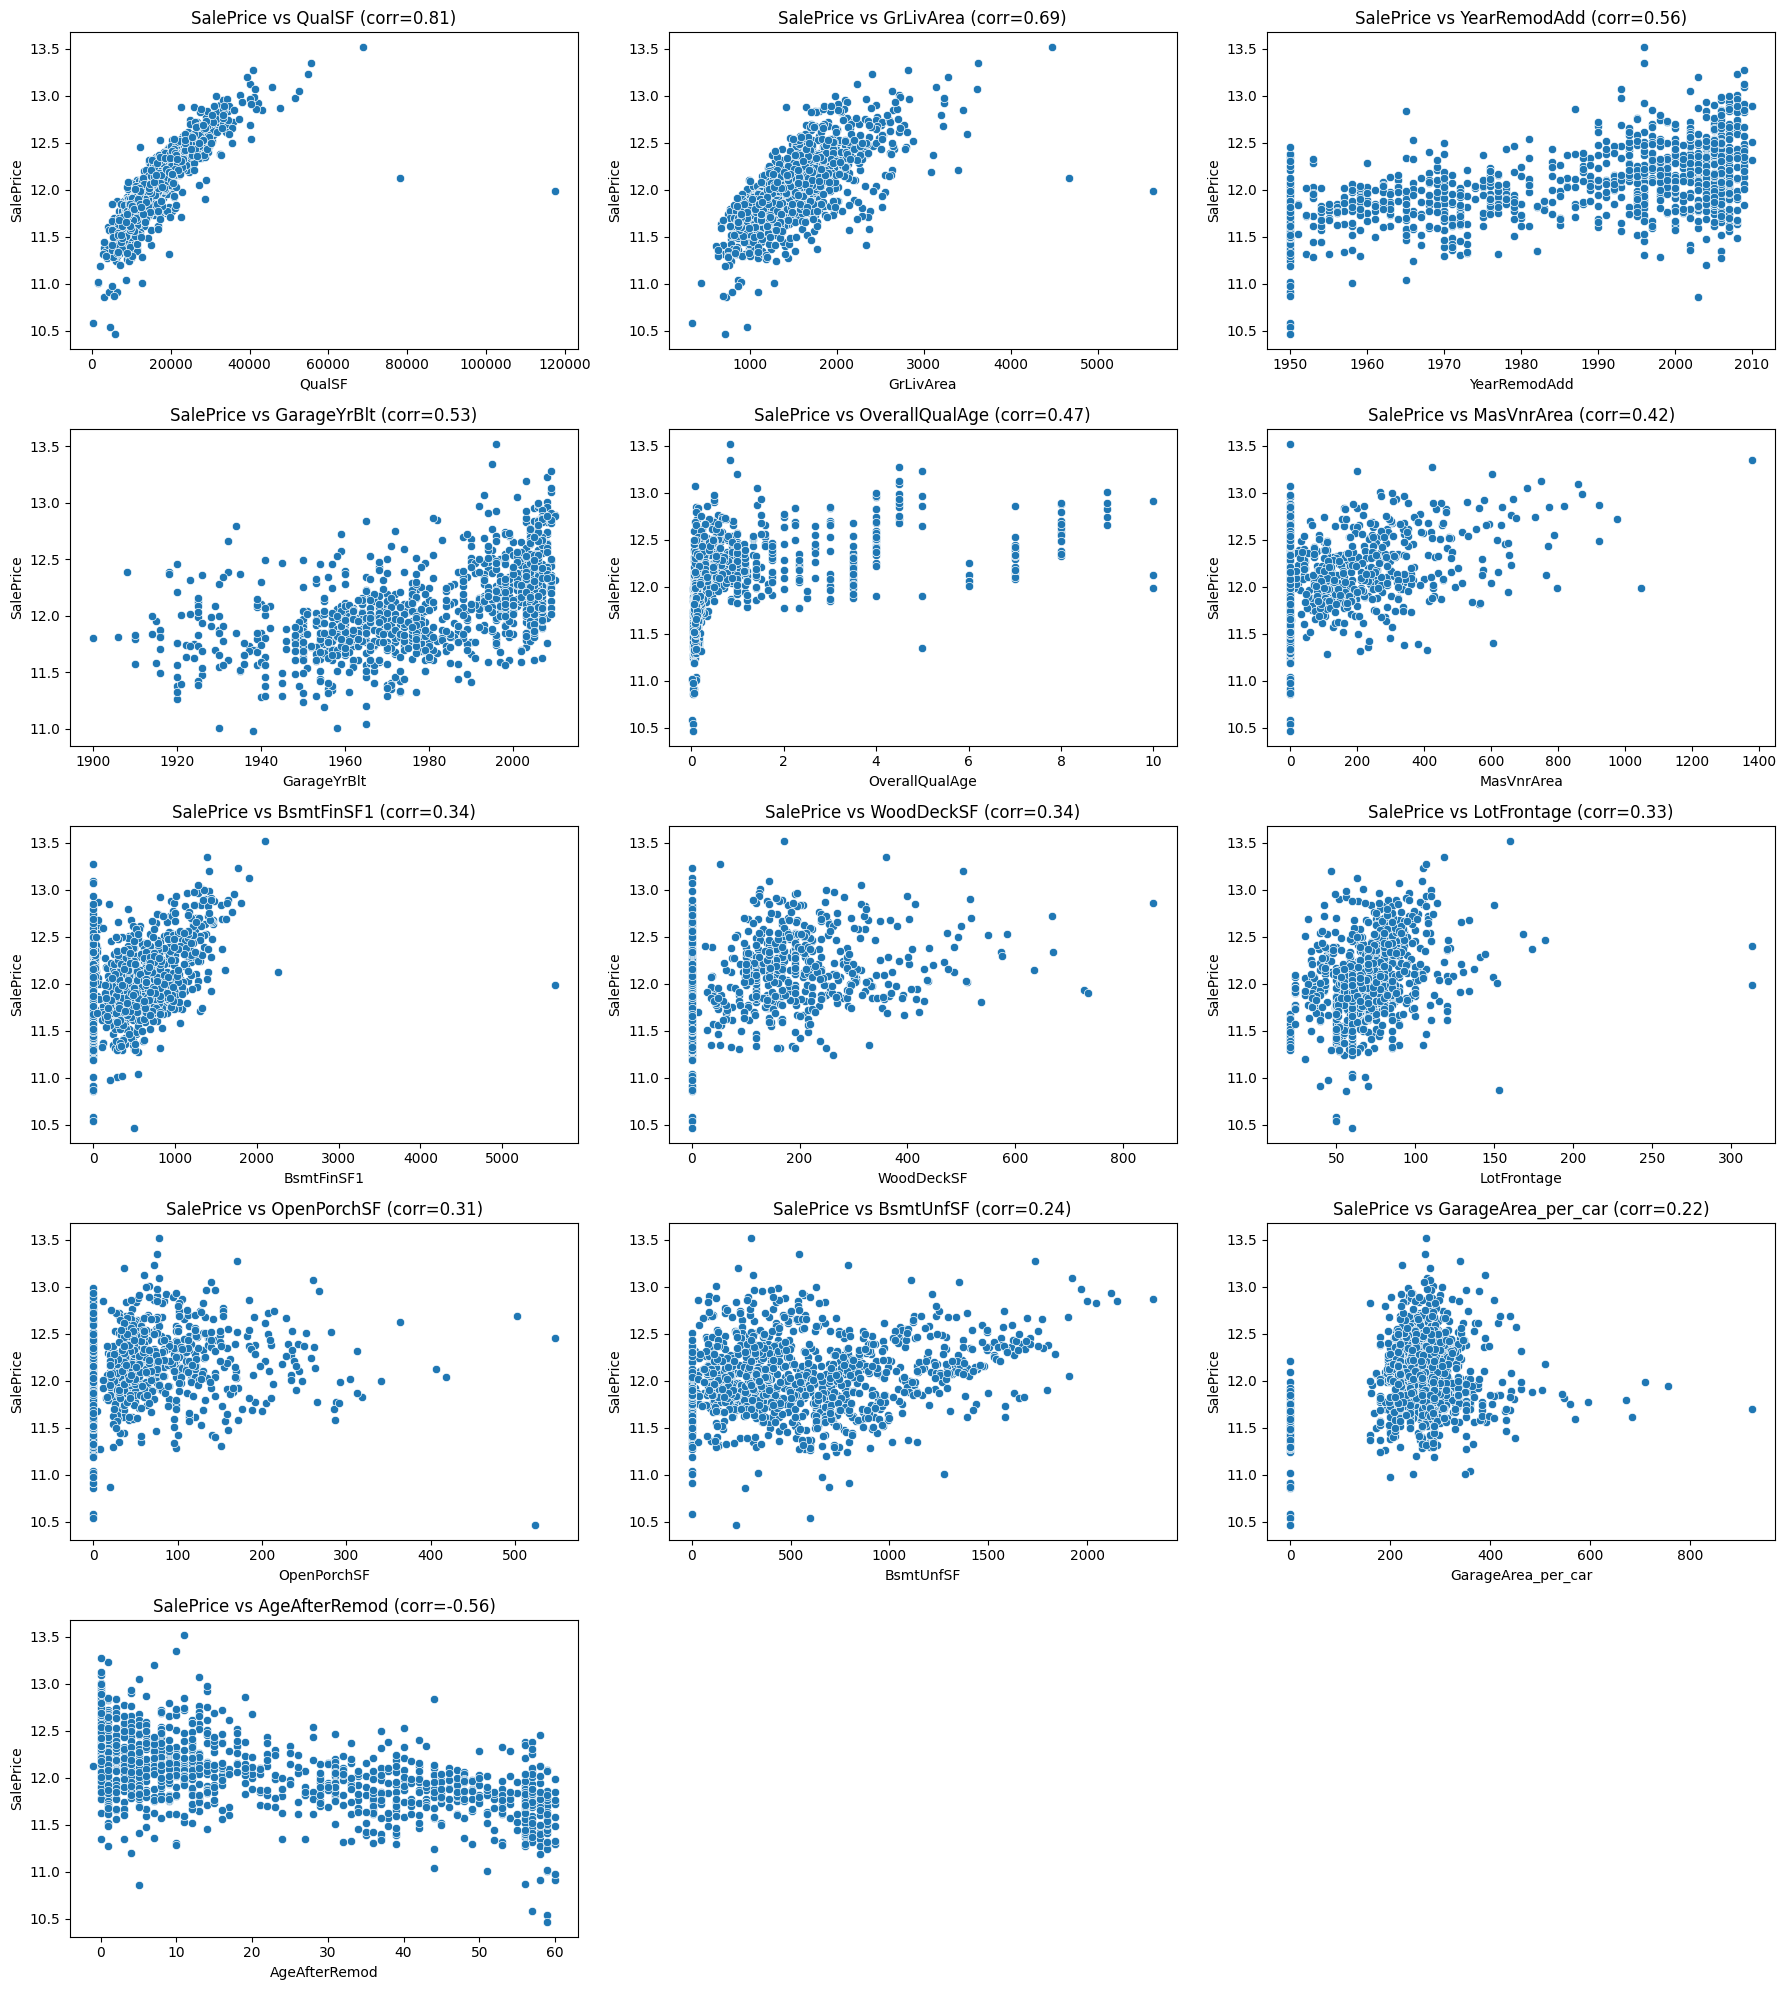

In [33]:
# Scatter plots for numerical features with high correlation - 3 plots per row
import math

num_features = len(continuous_numerical_features)
cols = 3

if num_features == 0:
    print("No contuinuous numerical features")
else:
    rows = math.ceil(num_features / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(continuous_numerical_features):
        sns.scatterplot(
            x=X_train[feature],
            y=y_train_log,
            ax=axes[i]
        )
        axes[i].set_title(f'SalePrice vs {feature} (corr={corr[feature]:.2f})')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('SalePrice')

    # Remove unused axes when number of features is not a multiple of 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [34]:
# Some features are in instable correlation with SalePrice, they will be deleted
instable_features = ["AgeAfterRemod", "LotFrontage"]
for feature in instable_features:
    X_train.drop(columns=feature, inplace=True)
    X_val.drop(columns=feature, inplace=True)
    X_test.drop(columns=feature, inplace=True)


In [35]:
# We have to separate binary features from continuous numerical features, 
# because they need to be treated differently in the preprocessing step. 
# We have to create binary features from continuous numerical features with a threshold, to capture the presence or absence of a feature. For example, for the feature "GarageCars", which represents the number of cars that can fit in the garage, we can create a binary feature "HasGarage" that indicates whether the house has a garage or not (1 if GarageCars > 0, 0 otherwise). This way, we can capture the effect of having a garage on the house price, regardless of the number of cars it can fit.

#Binary feature for GarageArea_per_car
X_train["HasGarage"] = (X_train["GarageArea_per_car"] > 0).astype(int)
X_val["HasGarage"] = (X_val["GarageArea_per_car"] > 0).astype(int)
X_test["HasGarage"] = (X_test["GarageArea_per_car"] > 0).astype(int)
# Deletion of the original feature after creating the binary feature to avoid multicollinearity issues
X_train.drop(columns="GarageArea_per_car", inplace=True)
X_val.drop(columns="GarageArea_per_car", inplace=True)
X_test.drop(columns="GarageArea_per_car", inplace=True)

# Binary feature for MasVnrArea
X_train["HasMasVnr"] = (X_train["MasVnrArea"] > 0).astype(int)
X_val["HasMasVnr"] = (X_val["MasVnrArea"] > 0).astype(int)
X_test["HasMasVnr"] = (X_test["MasVnrArea"] > 0).astype(int)
# Deletion of the original feature after creating the binary feature to avoid multicollinearity issues
X_train.drop(columns="MasVnrArea", inplace=True)
X_val.drop(columns="MasVnrArea", inplace=True)
X_test.drop(columns="MasVnrArea", inplace=True)

# Binary feature for WoodDeckSF
X_train["HasWoodDeck"] = (X_train["WoodDeckSF"] > 0).astype(int)
X_val["HasWoodDeck"] = (X_val["WoodDeckSF"] > 0).astype(int)
X_test["HasWoodDeck"] = (X_test["WoodDeckSF"] > 0).astype(int)
# Deletion of the original feature after creating the binary feature to avoid multicollinearity issues
X_train.drop(columns="WoodDeckSF", inplace=True)
X_val.drop(columns="WoodDeckSF", inplace=True)
X_test.drop(columns="WoodDeckSF", inplace=True)

# Binary feature for OpenPorchSF
X_train["HasOpenPorch"] = (X_train["OpenPorchSF"] > 0).astype(int)
X_val["HasOpenPorch"] = (X_val["OpenPorchSF"] > 0).astype(int)
X_test["HasOpenPorch"] = (X_test["OpenPorchSF"] > 0).astype(int)
# Deletion of the original feature after creating the binary feature to avoid multicollinearity issues
X_train.drop(columns="OpenPorchSF", inplace=True)
X_val.drop(columns="OpenPorchSF", inplace=True)
X_test.drop(columns="OpenPorchSF", inplace=True)


In [36]:
# update of the list of numerical features
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_features

['YearRemodAdd',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'LowQualFinSF',
 'GrLivArea',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'ExterQual num',
 'ExterCond num',
 'BsmtQual num',
 'BsmtCond num',
 'HeatingQC num',
 'KitchenQual num',
 'FireplaceQu num',
 'GarageQual num',
 'GarageCond num',
 'PoolQC num',
 'BsmtExposure num',
 'BsmtFinType1 num',
 'BsmtFinType2 num',
 'Functional num',
 'GarageFinish num',
 'PavedDrive num',
 'LandSlope num',
 'OverallQual num',
 'OverallCond num',
 'TotalBath',
 'OverallQualAge',
 'QualSF',
 'HasGarage',
 'HasMasVnr',
 'HasWoodDeck',
 'HasOpenPorch']

In [37]:
# Recalculate continuous_numerical_features after all transformations
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
continuous_numerical_features = [col for col in numerical_features if X_train[col].nunique() > 20]

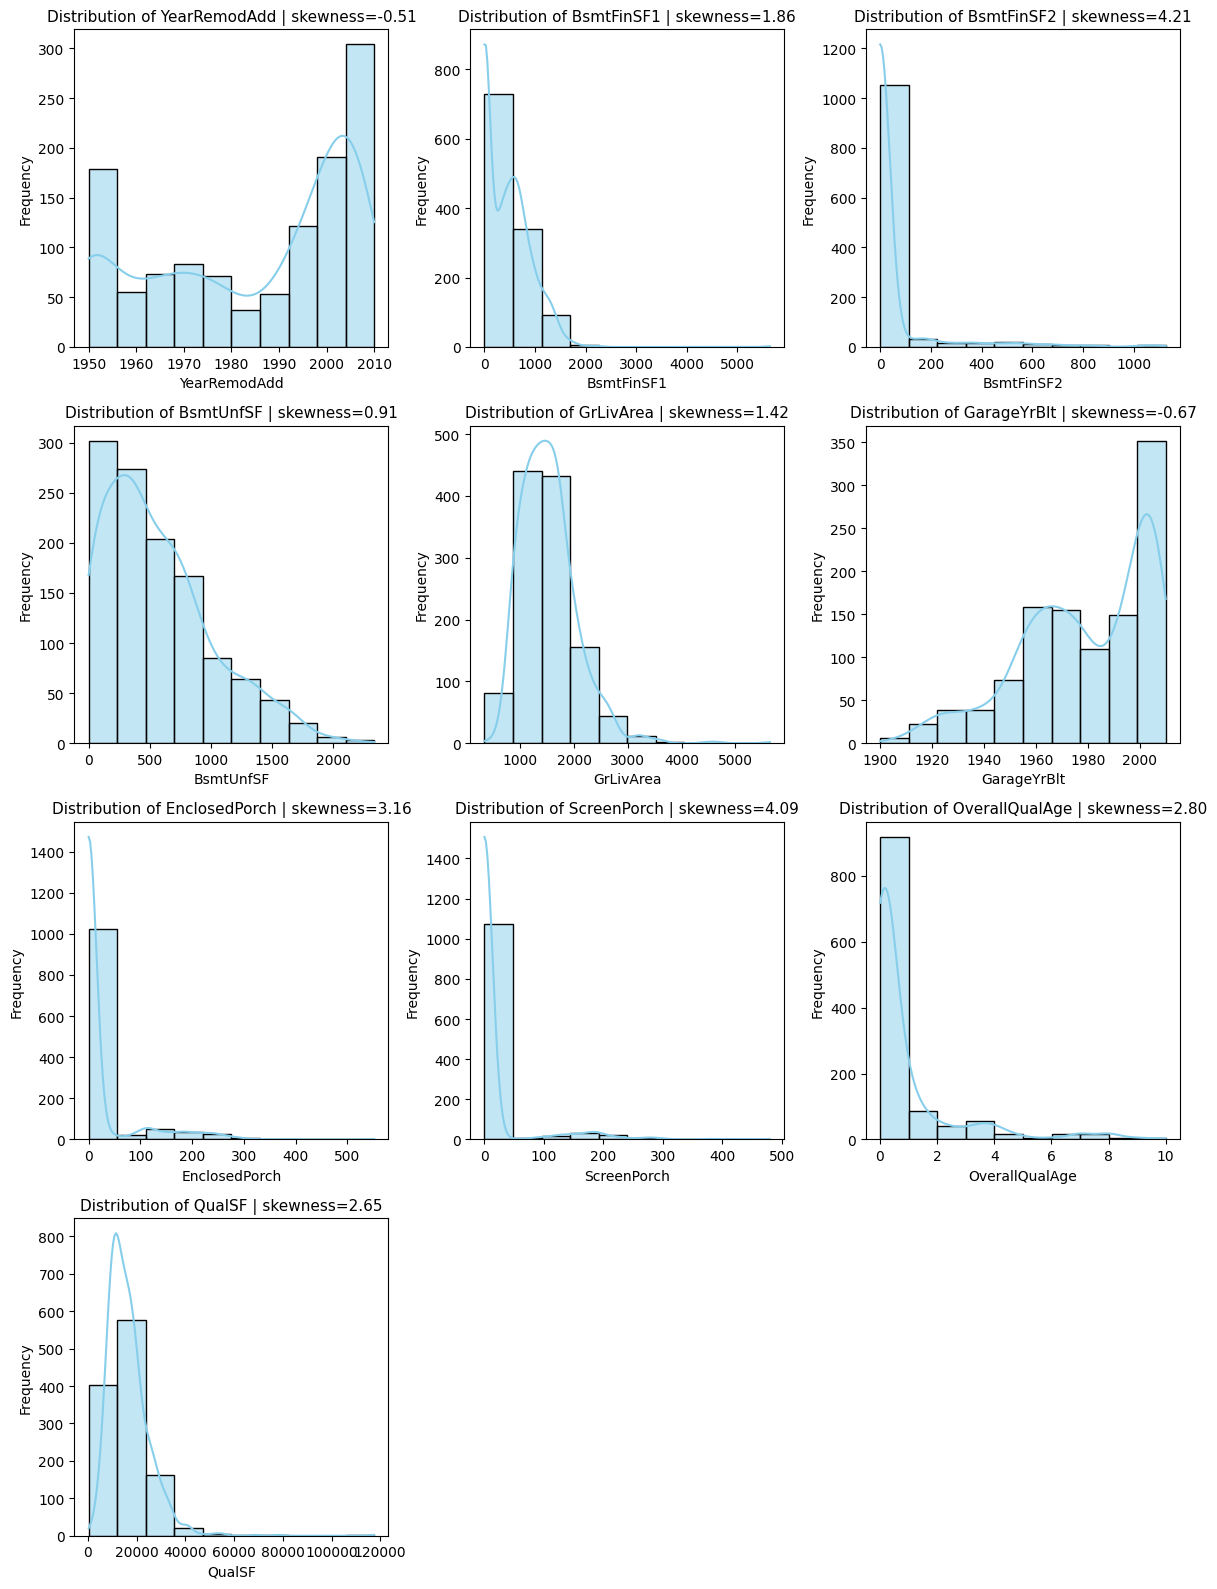

In [38]:
# Histogram for continuous numerical features - 3 plots per row

import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import skew

# Nombre total de colonnes numériques
num_cols = len(continuous_numerical_features)

# 3 graphiques par ligne
cols = 3
rows = math.ceil(num_cols / cols)

# Créer la grille de sous-graphiques
fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()

# Boucle sur les colonnes numériques
for i, col in enumerate(continuous_numerical_features):
    series = X_train[col].dropna()

    sns.histplot(
        series,
        bins=10,
        kde=True,                  # Ajoute la courbe de densité (lissage)
        color='skyblue',
        edgecolor='black',
        ax=axes[i]
    )

    # Affiche la skewness pour les colonnes numériques
    if pd.api.types.is_numeric_dtype(series):
        sk = skew(series)
        axes[i].set_title(f'Distribution of {col} | skewness={sk:.2f}', fontsize=11)
    else:
        axes[i].set_title(f'Distribution of {col} | skewness=N/A', fontsize=11)

    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Supprimer les axes inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

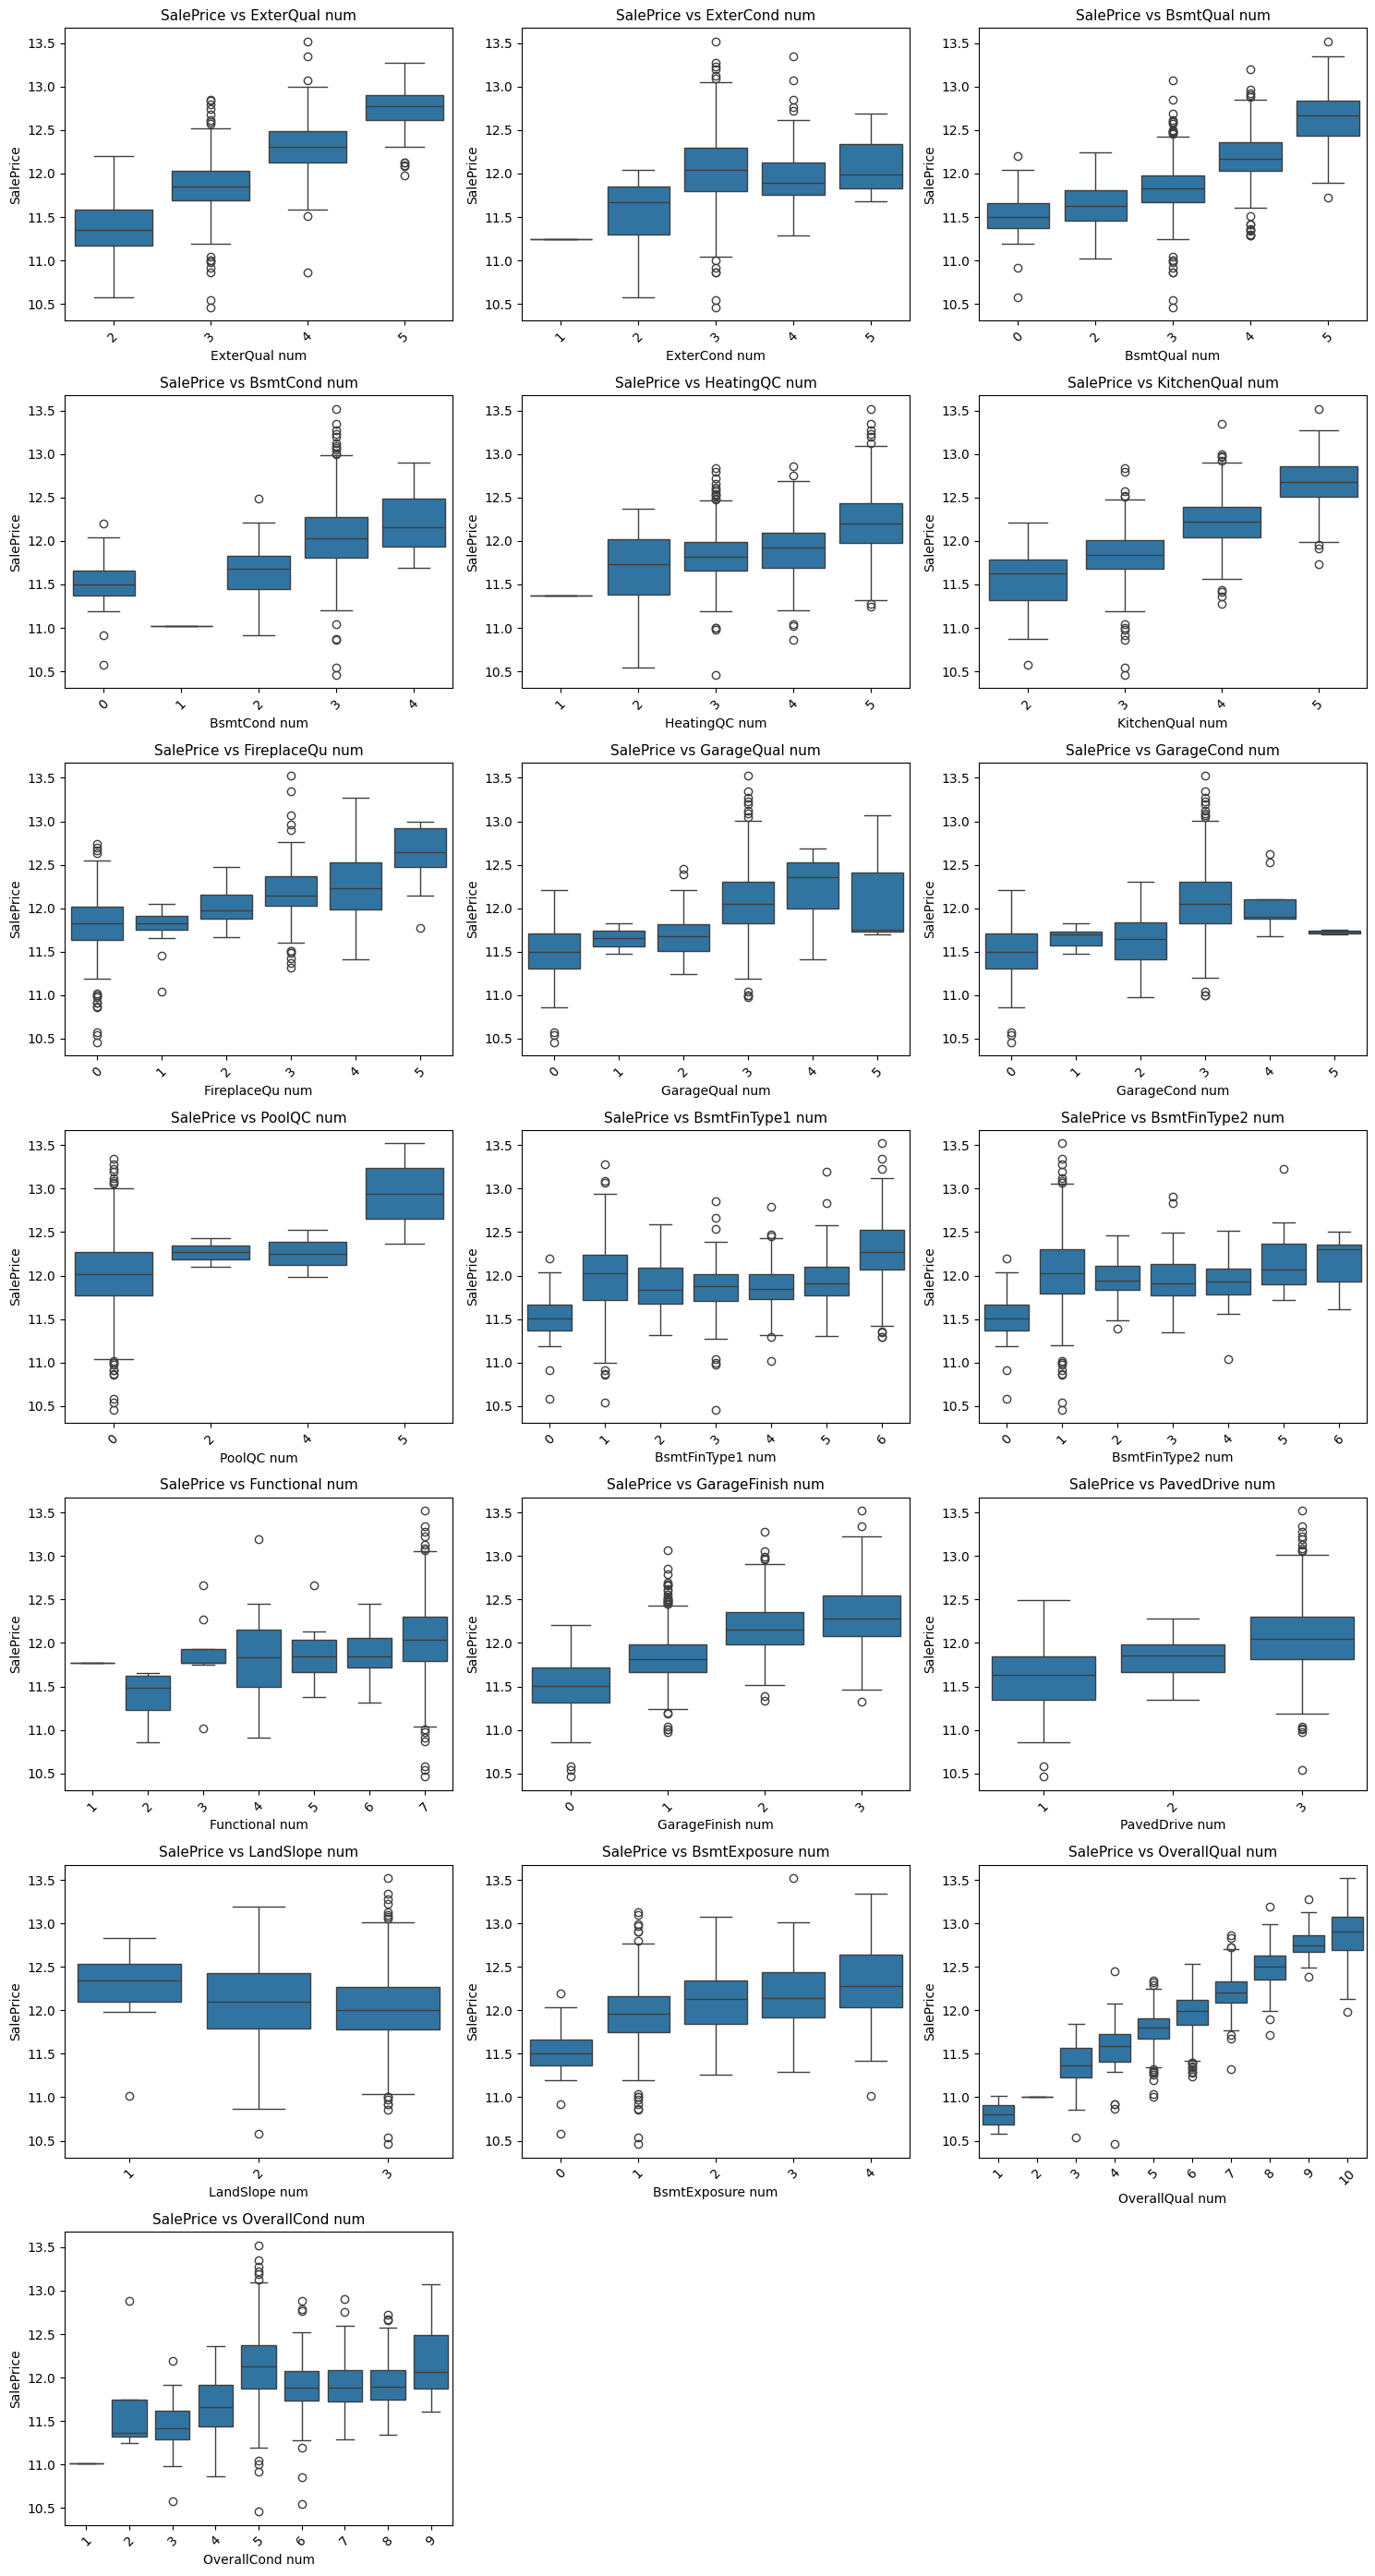

In [39]:
# Box plot for all ordinal features - 3 plots per row
num_cat_features = len(ordinal_features)
cols = 3
rows = math.ceil(num_cat_features / cols)

# Create subplot grid
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = np.array(axes).reshape(-1)

# Loop through ordinal features
for i, feature in enumerate(ordinal_features):
    if feature not in X_train.columns:
        continue

    plot_df = (
        X_train[[feature]]
        .join(y_train_log.rename("SalePrice"), how="inner")
        .dropna(subset=[feature, "SalePrice"])
    )

    if plot_df.empty:
        continue

    sns.boxplot(data=plot_df, x=feature, y="SalePrice", ax=axes[i])
    axes[i].set_title(f"SalePrice vs {feature}", fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("SalePrice")
    axes[i].tick_params(axis="x", rotation=45)

# Remove unused axes
last_i = i if len(ordinal_features) > 0 else -1
for j in range(last_i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [40]:
#diplay KitchenAbvGr type
print(X_train.KitchenAbvGr.dtype)

int64


In [41]:
#Display the percentage for each values for the feature "KitchenAbvGr" to check if it is a binary feature or not
print(X_train.KitchenAbvGr.value_counts(normalize=True) * 100)

#display correlation between KitchenAbvGr and the target variable
corr_kitchenabvgr = X_train["KitchenAbvGr"].corr(y_train_log)
print(f"Correlation between KitchenAbvGr and SalePrice: {corr_kitchenabvgr:.2f}")

KitchenAbvGr
1    95.205479
2     4.537671
3     0.171233
0     0.085616
Name: proportion, dtype: float64
Correlation between KitchenAbvGr and SalePrice: -0.16


In [42]:
# Transformation of the feature "KitchenAbvGr" into several binary features "HasKitchenAbvGr" that indicates whether
# the house has more than one kitchen above ground or zero above ground
X_train["HasKitchenAbvGr"] = (X_train["KitchenAbvGr"] > 1).astype(int)
X_val["HasKitchenAbvGr"] = (X_val["KitchenAbvGr"] > 1).astype(int)
X_test["HasKitchenAbvGr"] = (X_test["KitchenAbvGr"] > 1).astype(int)
X_train["HasNoKitchenAbvGr"] = (X_train["KitchenAbvGr"] == 0).astype(int)
X_val["HasNoKitchenAbvGr"] = (X_val["KitchenAbvGr"] == 0).astype(int)
X_test["HasNoKitchenAbvGr"] = (X_test["KitchenAbvGr"] == 0).astype(int)
#deletion of the original feature "KitchenAbvGr" after transformation
X_train.drop(columns=["KitchenAbvGr"], inplace=True)
X_val.drop(columns=["KitchenAbvGr"], inplace=True)
X_test.drop(columns=["KitchenAbvGr"], inplace=True)


In [43]:
# Numerical feature list update
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Updated numerical features:", numerical_features)

Updated numerical features: ['YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'LowQualFinSF', 'GrLivArea', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'ExterQual num', 'ExterCond num', 'BsmtQual num', 'BsmtCond num', 'HeatingQC num', 'KitchenQual num', 'FireplaceQu num', 'GarageQual num', 'GarageCond num', 'PoolQC num', 'BsmtExposure num', 'BsmtFinType1 num', 'BsmtFinType2 num', 'Functional num', 'GarageFinish num', 'PavedDrive num', 'LandSlope num', 'OverallQual num', 'OverallCond num', 'TotalBath', 'OverallQualAge', 'QualSF', 'HasGarage', 'HasMasVnr', 'HasWoodDeck', 'HasOpenPorch', 'HasKitchenAbvGr', 'HasNoKitchenAbvGr']


In [44]:
# Categorical feature list update
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
categorical_features

['MSZoning',
 'LotShape',
 'LandContour',
 'LotConfig',
 'Neighborhood',
 'Condition1',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'Foundation',
 'Heating',
 'CentralAir',
 'Electrical',
 'GarageType',
 'SaleType',
 'SaleCondition',
 'MSSubClass cat']

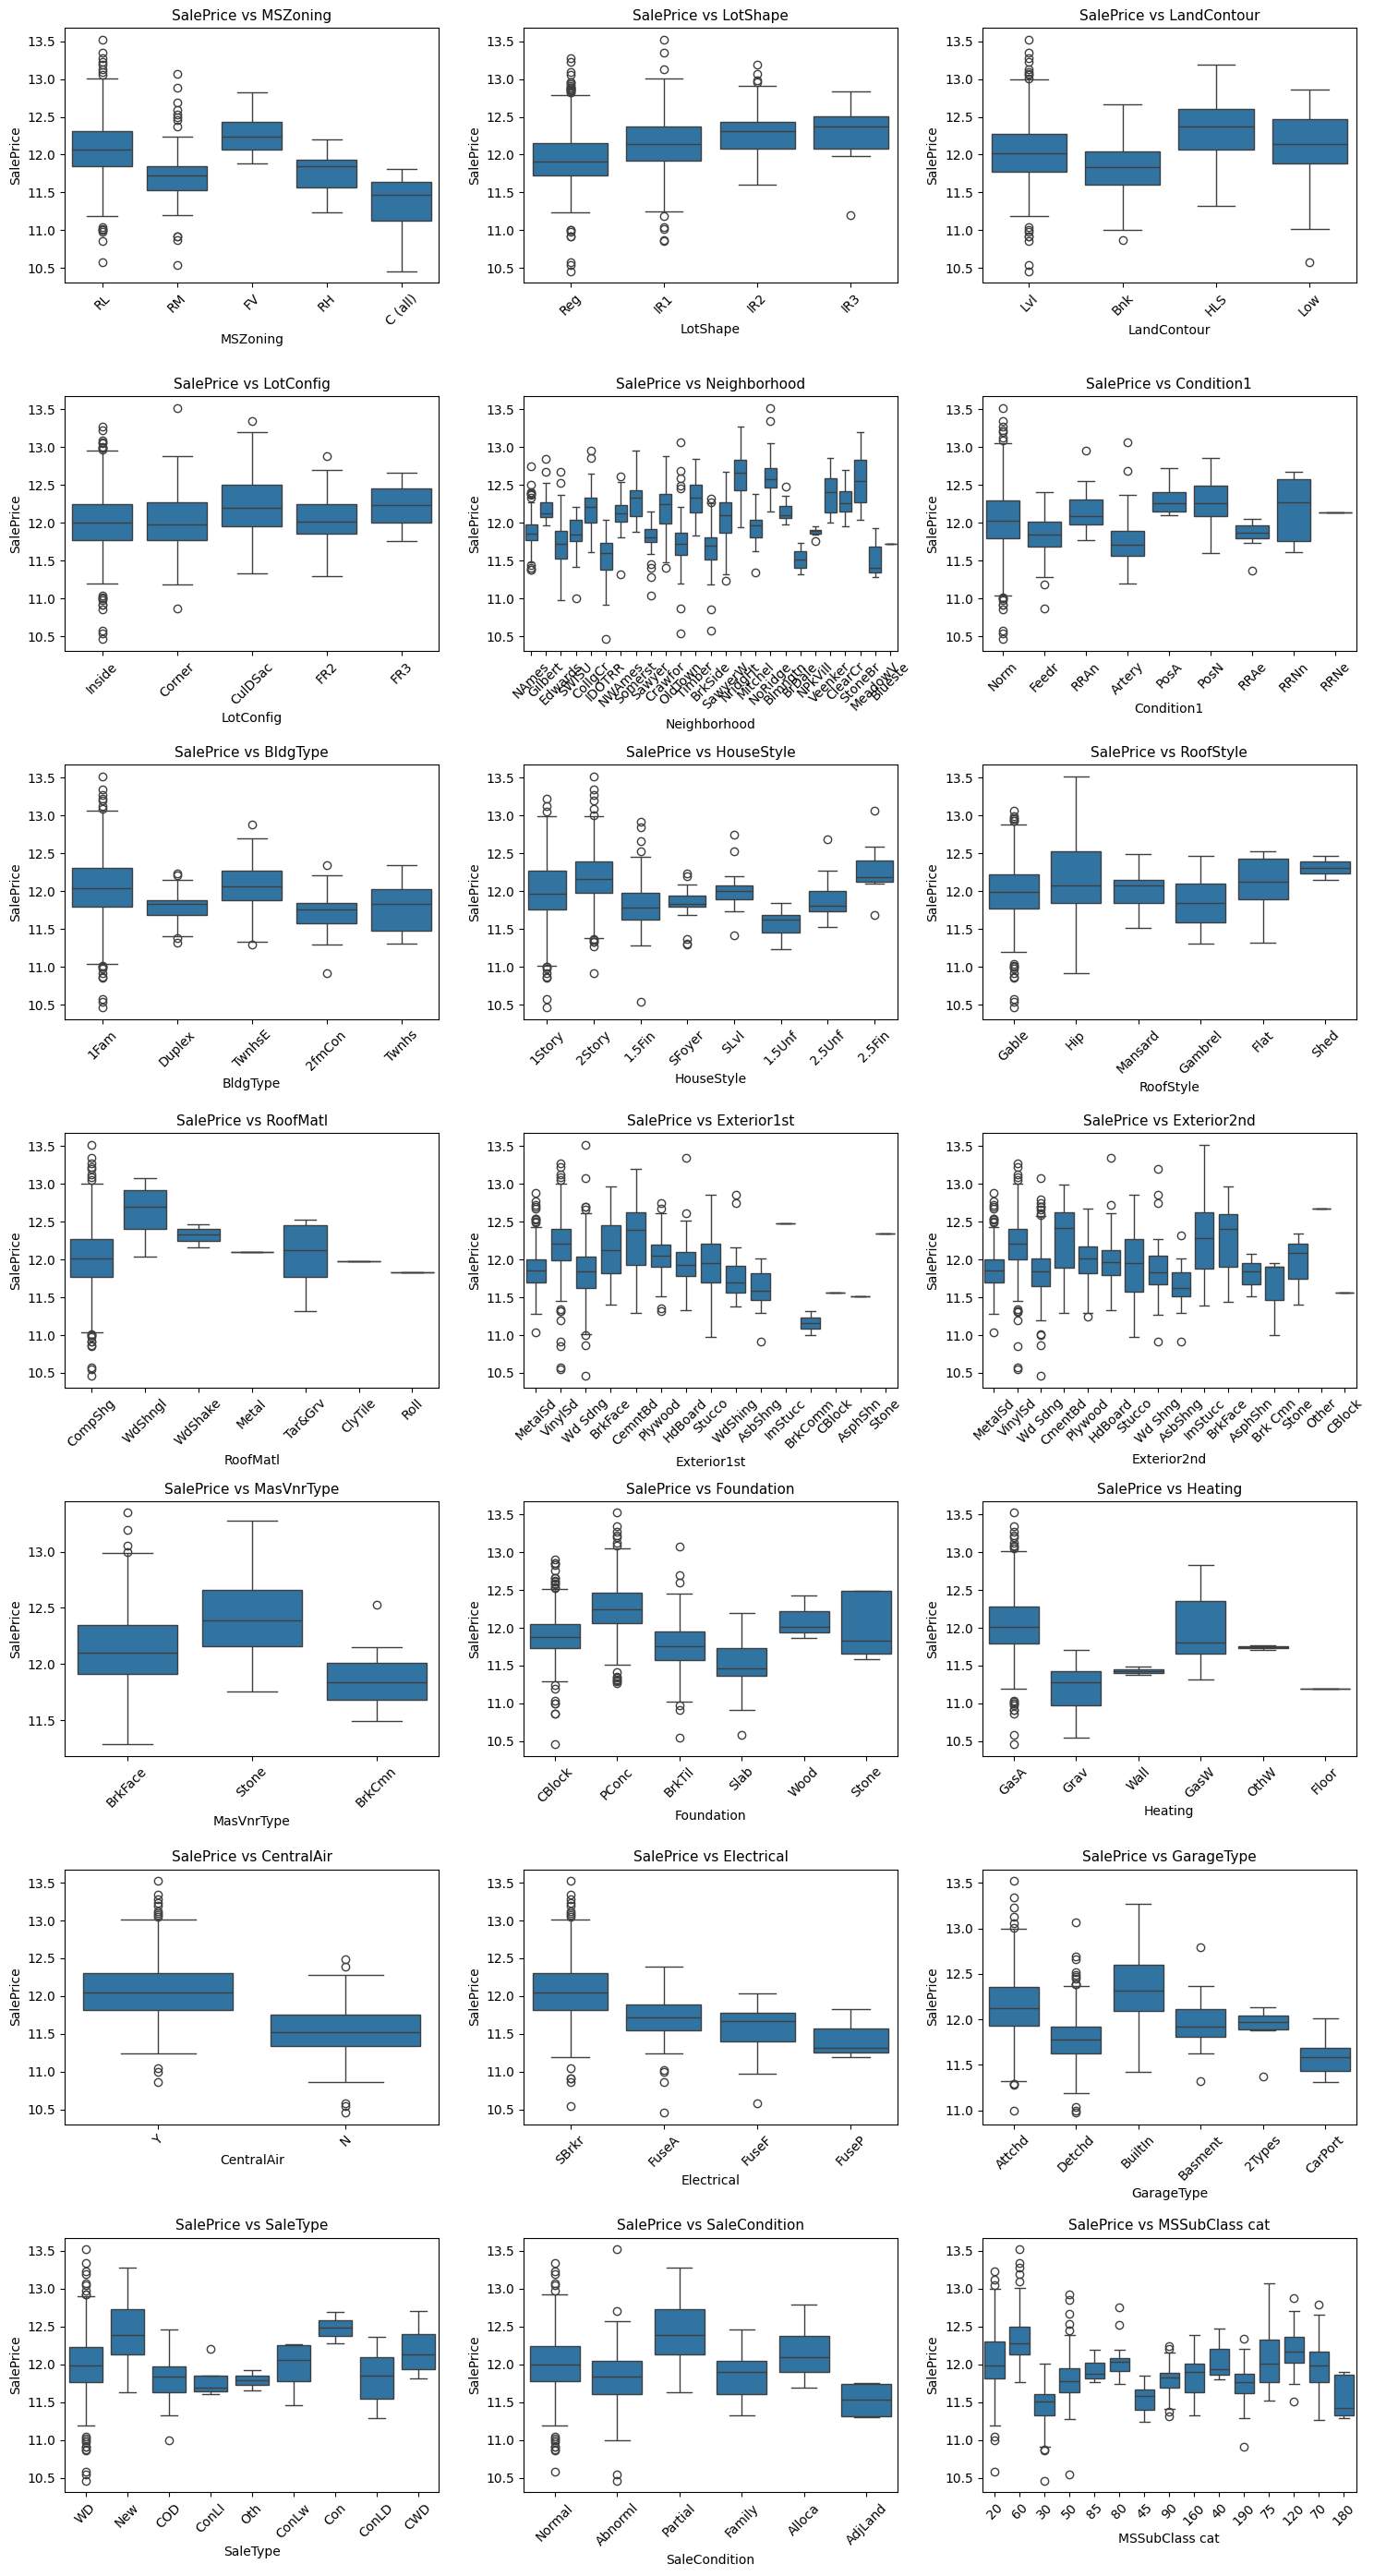

In [45]:
# Box plot for all categorical features except ordinal features - 3 plots per row
num_cat_features = len(categorical_features) 
cols = 3
rows = math.ceil(num_cat_features / cols)

# Create subplot grid
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

# Loop through categorical features
for i, feature in enumerate(categorical_features):
    sns.boxplot(x=X_train[feature], y=y_train_log, ax=axes[i])
    axes[i].set_title(f'SalePrice vs {feature}', fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('SalePrice')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [46]:
# Transformation of CentralAir feature into a binary feature "HasCentralAir" 
# that indicates whether the house has central air conditioning or not
X_train["HasCentralAir"] = (X_train["CentralAir"] == "Y").astype(int)
X_val["HasCentralAir"] = (X_val["CentralAir"] == "Y").astype(int)
X_test["HasCentralAir"] = (X_test["CentralAir"] == "Y").astype(int)
# Deletion of the original feature "CentralAir" after transformation
X_train.drop(columns=["CentralAir"], inplace=True)
X_val.drop(columns=["CentralAir"], inplace=True)
X_test.drop(columns=["CentralAir"], inplace=True)



In [47]:
#update of the list of categorical features after transformation
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
#update of the list of numerical features after transformation
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [48]:
# Transormation of LotShape feature into ordonal feature with mapping based on the order of the categories in data description
lotshape_mapping = {"Reg": 4, "IR1": 3, "IR2": 2, "IR3": 1}
X_train["LotShape num"] = X_train["LotShape"].map(lotshape_mapping)
X_val["LotShape num"] = X_val["LotShape"].map(lotshape_mapping)
X_test["LotShape num"] = X_test["LotShape"].map(lotshape_mapping)
# Deletion of the original feature "LotShape" after transformation
X_train.drop(columns=["LotShape"], inplace=True)
X_val.drop(columns=["LotShape"], inplace=True)
X_test.drop(columns=["LotShape"], inplace=True)
#update of the list of categorical features after transformation
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
#update of the list of numerical features after transformation
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [49]:
X_train[numerical_features+categorical_features].head(5)

,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,LowQualFinSF,GrLivArea,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,...,Exterior1st,Exterior2nd,MasVnrType,Foundation,Heating,Electrical,GarageType,SaleType,SaleCondition,MSSubClass cat
Id,,,,,,,,,,,,,,,,,,,,,
255,1957,922,0,392,0,1314,3,5,0,1957.0,...,MetalSd,MetalSd,NaN,CBlock,GasA,SBrkr,Attchd,WD,Normal,20
1067,1994,0,0,799,0,1571,3,7,1,1993.0,...,VinylSd,VinylSd,NaN,PConc,GasA,SBrkr,Attchd,WD,Normal,60
639,1950,0,0,796,0,796,2,4,0,NaN,...,MetalSd,Wd Sdng,NaN,CBlock,GasA,FuseA,NaN,WD,Normal,30
800,1950,569,0,162,0,1768,3,7,2,1939.0,...,Wd Sdng,Wd Sdng,BrkFace,BrkTil,GasA,SBrkr,Detchd,WD,Normal,50
381,1950,218,0,808,0,1691,3,6,1,1924.0,...,BrkFace,Wd Sdng,NaN,BrkTil,GasA,SBrkr,Detchd,WD,Normal,50


In [50]:
feature_list = X_train.columns.to_list()
print(feature_list)

['MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'Heating', 'Electrical', 'LowQualFinSF', 'GrLivArea', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageType', 'GarageYrBlt', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'MSSubClass cat', 'ExterQual num', 'ExterCond num', 'BsmtQual num', 'BsmtCond num', 'HeatingQC num', 'KitchenQual num', 'FireplaceQu num', 'GarageQual num', 'GarageCond num', 'PoolQC num', 'BsmtExposure num', 'BsmtFinType1 num', 'BsmtFinType2 num', 'Functional num', 'GarageFinish num', 'PavedDrive num', 'LandSlope num', 'OverallQual num', 'OverallCond num', 'TotalBath', 'OverallQualAge', 'QualSF', 'HasGarage', 'HasMasVnr', 'HasWoodDeck', 'HasOpenPorch', 'HasKitchenAbvGr', 'HasNoKitchenAbvGr', 'HasCentralAir', 'L

In [51]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_val = X_val.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

In [52]:
continuous_numerical_features = [col for col in numerical_top_features if col in X_train.columns and X_train[col].nunique() > 20]

In [53]:
from scipy.stats import skew

# Identify numerical features with high skewness (threshold = 1)
skewness = X_train[continuous_numerical_features].apply(lambda col: skew(col.dropna()))
skewed_cols = skewness[abs(skewness) > 1].index.tolist()

print(f"Colonnes transformées avec log1p ({len(skewed_cols)}) :")
print(skewed_cols)

# Apply log1p to skewed columns (log1p handles zeros safely)
X_train[skewed_cols] = np.log1p(X_train[skewed_cols].clip(lower=0))
X_val[skewed_cols] = np.log1p(X_val[skewed_cols].clip(lower=0))
X_test[skewed_cols] = np.log1p(X_test[skewed_cols].clip(lower=0))


Colonnes transformées avec log1p (4) :
['QualSF', 'GrLivArea', 'OverallQualAge', 'BsmtFinSF1']


In [54]:
continuous_numerical_features = [col for col in numerical_top_features if col in X_train.columns and X_train[col].nunique() > 20]

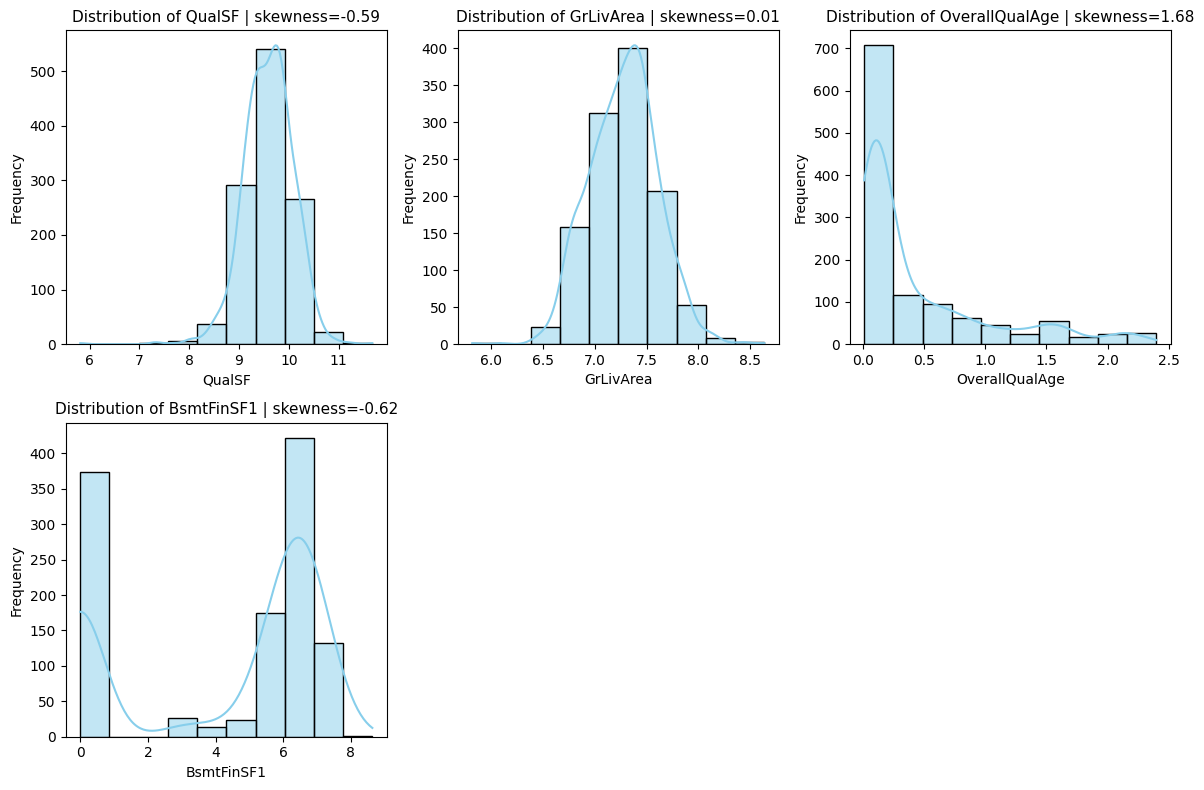

In [55]:
# Histogram for log skewed numerical features - 3 plots per row

import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import skew

# Nombre total de colonnes numériques
num_cols = len(skewed_cols)

# 3 graphiques par ligne
cols = 3
rows = math.ceil(num_cols / cols)

# Créer la grille de sous-graphiques
fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()

# Boucle sur les colonnes numériques
for i, col in enumerate(skewed_cols):
    series = X_train[col].dropna()

    sns.histplot(
        series,
        bins=10,
        kde=True,                  # Ajoute la courbe de densité (lissage)
        color='skyblue',
        edgecolor='black',
        ax=axes[i]
    )

    # Affiche la skewness pour les colonnes numériques
    if pd.api.types.is_numeric_dtype(series):
        sk = skew(series)
        axes[i].set_title(f'Distribution of {col} | skewness={sk:.2f}', fontsize=11)
    else:
        axes[i].set_title(f'Distribution of {col} | skewness=N/A', fontsize=11)

    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Supprimer les axes inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

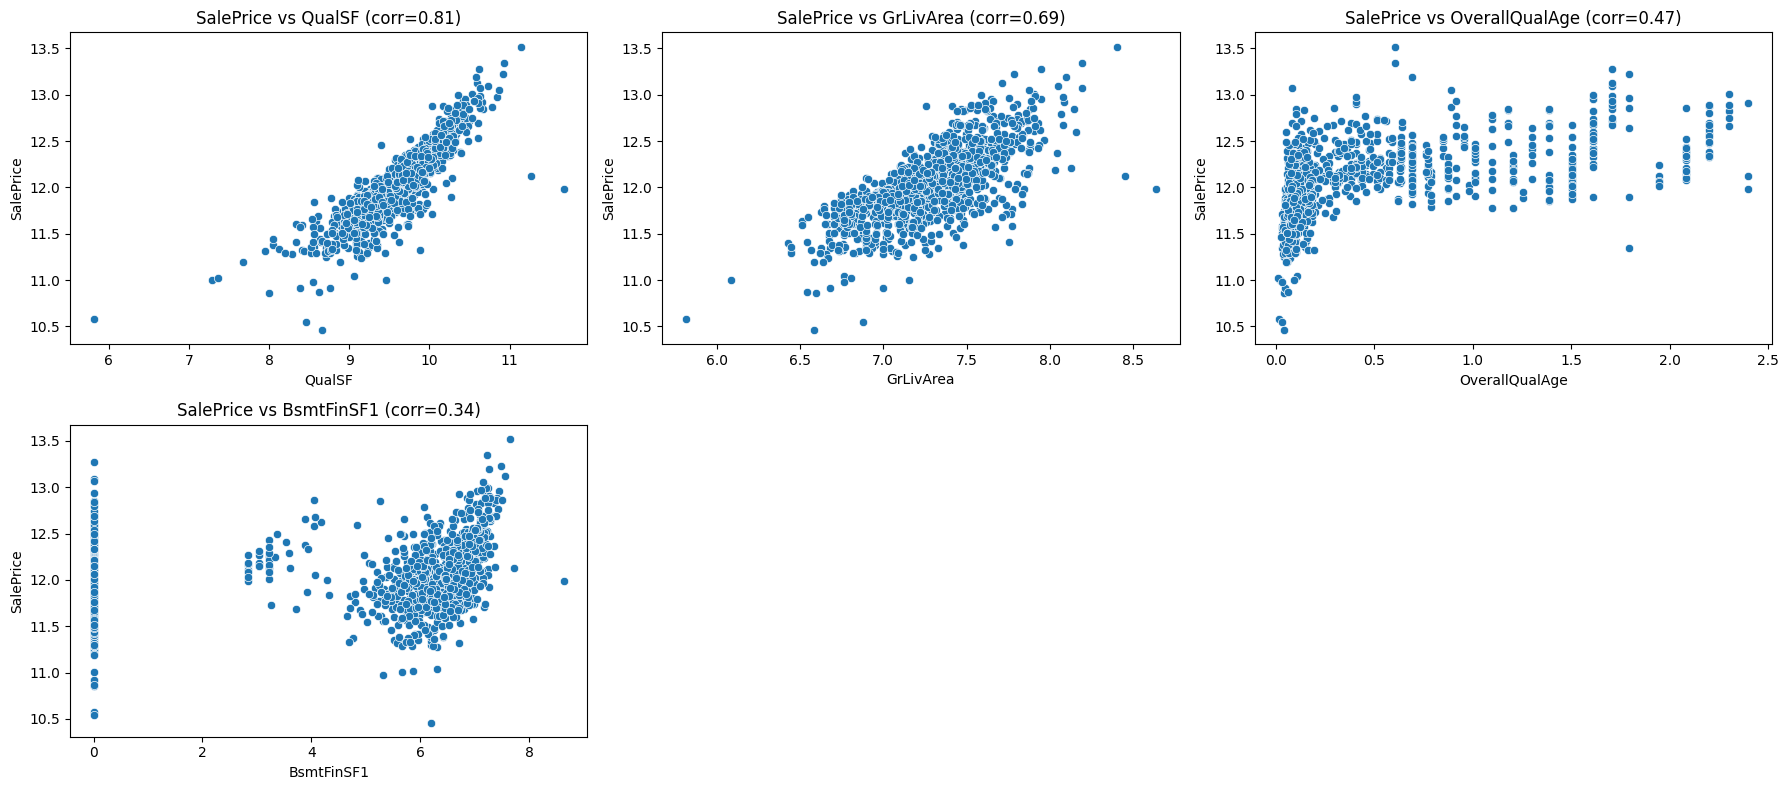

In [56]:
# Scatter plots for log skewed numerical features with high correlation - 3 plots per row
import math
num_skewed_features = len(skewed_cols)
cols = 3

if num_skewed_features == 0:
    print("No feature skewed")
else:
    rows = math.ceil(num_skewed_features / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(skewed_cols):
        sns.scatterplot(
            x=X_train[feature],
            y=y_train_log,
            ax=axes[i]
        )
        axes[i].set_title(f'SalePrice vs {feature} (corr={corr[feature]:.2f})')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('SalePrice')

    # Remove unused axes when number of features is not a multiple of 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [57]:
# Remove constant features (including columns that are entirely NaN)
constant_cols = [col for col in X_train[numerical_features+categorical_features].columns if X_train[col].nunique(dropna=False) <= 1]

print(f"Nombre de features constantes supprimées: {len(constant_cols)}")
if constant_cols:
    print(constant_cols)

X_train = X_train.drop(columns=constant_cols)
X_val = X_val.drop(columns=constant_cols, errors='ignore')
X_test = X_test.drop(columns=constant_cols, errors='ignore')

# Update of numerical and categorical features list after removing constant features
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

Nombre de features constantes supprimées: 0


In [58]:
#recalculate correlation on numeric features
cols_to_include = list(numerical_features) + ["SalePrice"]
df_corr = (
    X_train
    .assign(SalePrice=y_train_log.values)[cols_to_include]
)
corr = df_corr.corr()["SalePrice"].sort_values(ascending=False)
print(corr.head(35))

SalePrice           1.000000
QualSF              0.868377
OverallQual num     0.807946
GrLivArea           0.723567
KitchenQual num     0.667939
ExterQual num       0.660159
TotalBath           0.659371
BsmtQual num        0.622365
GarageFinish num    0.607353
YearRemodAdd        0.562152
OverallQualAge      0.559213
FireplaceQu num     0.541509
GarageYrBlt         0.530321
TotRmsAbvGrd        0.520082
HeatingQC num       0.484609
Fireplaces          0.481761
HasOpenPorch        0.454871
GarageQual num      0.376042
GarageCond num      0.366829
HasCentralAir       0.364676
HasMasVnr           0.364073
BsmtExposure num    0.357203
HasWoodDeck         0.344613
HasGarage           0.341743
BsmtFinType1 num    0.313494
PavedDrive num      0.297730
BsmtCond num        0.283268
BsmtUnfSF           0.235227
BedroomAbvGr        0.193340
BsmtFinSF1          0.175344
Functional num      0.145151
ScreenPorch         0.123040
PoolQC num          0.093971
PoolArea            0.084116
3SsnPorch     

In [59]:
# update total list of features after all transformations
feature_list = X_train.columns.to_list()
print(f"Total number of features after preprocessing: {len(feature_list)}")
print(feature_list)

Total number of features after preprocessing: 66
['MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'Heating', 'Electrical', 'LowQualFinSF', 'GrLivArea', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageType', 'GarageYrBlt', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'MSSubClass cat', 'ExterQual num', 'ExterCond num', 'BsmtQual num', 'BsmtCond num', 'HeatingQC num', 'KitchenQual num', 'FireplaceQu num', 'GarageQual num', 'GarageCond num', 'PoolQC num', 'BsmtExposure num', 'BsmtFinType1 num', 'BsmtFinType2 num', 'Functional num', 'GarageFinish num', 'PavedDrive num', 'LandSlope num', 'OverallQual num', 'OverallCond num', 'TotalBath', 'OverallQualAge', 'QualSF', 'HasGarage', 'HasMasVnr', 'HasWoodDeck', 'HasOpenPorch', 'HasKitche

# 4. Preprocessing pipeline and train a baseline model (RandomForest)
For initial performance evaluation

In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

cat_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy= 'constant', fill_value='None')), 
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
num_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy= 'median')), 
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(transformers = [
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
], remainder='drop' # only keeps the num+cat columns
)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=500,
        max_depth=12,
        min_samples_split=8,
        min_samples_leaf=2,
        max_features=0.7,
        random_state=42,
        n_jobs=4
        ))
])
model.fit(X_train, y_train_log)
y_train_log_pred = model.predict(X_train)
y_val_log_pred   = model.predict(X_val)


from sklearn.metrics import root_mean_squared_error, r2_score
print("Train log RMSE :", root_mean_squared_error(y_train_log, y_train_log_pred))
print("Train log R²:", r2_score(y_train_log, y_train_log_pred))
print("Validation log RMSE :", root_mean_squared_error(y_val_log, y_val_log_pred))
print("Validation log R²:", r2_score(y_val_log, y_val_log_pred))

y_train = np.expm1(y_train_log)          # Inverse of log1p
y_train_pred = np.expm1(y_train_log_pred) 

y_val = np.expm1(y_val_log)          # Inverse of log1p
y_val_pred = np.expm1(y_val_log_pred) 


Train log RMSE : 0.07495607822420185
Train log R²: 0.9631440310904048
Validation log RMSE : 0.14548964274489604
Validation log R²: 0.8865702587715584


In [61]:
# list of the features used in the model after preprocessing
feature_names = X_train.columns.tolist()
print("Features used in the model after preprocessing:")
print(feature_names)

Features used in the model after preprocessing:
['MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'Heating', 'Electrical', 'LowQualFinSF', 'GrLivArea', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageType', 'GarageYrBlt', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'MSSubClass cat', 'ExterQual num', 'ExterCond num', 'BsmtQual num', 'BsmtCond num', 'HeatingQC num', 'KitchenQual num', 'FireplaceQu num', 'GarageQual num', 'GarageCond num', 'PoolQC num', 'BsmtExposure num', 'BsmtFinType1 num', 'BsmtFinType2 num', 'Functional num', 'GarageFinish num', 'PavedDrive num', 'LandSlope num', 'OverallQual num', 'OverallCond num', 'TotalBath', 'OverallQualAge', 'QualSF', 'HasGarage', 'HasMasVnr', 'HasWoodDeck', 'HasOpenPorch', 'HasKitchen

In [62]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 255 to 1127
Data columns (total 66 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MSZoning           1168 non-null   object 
 1   LandContour        1168 non-null   object 
 2   LotConfig          1168 non-null   object 
 3   Neighborhood       1168 non-null   object 
 4   Condition1         1168 non-null   object 
 5   BldgType           1168 non-null   object 
 6   HouseStyle         1168 non-null   object 
 7   YearRemodAdd       1168 non-null   int64  
 8   RoofStyle          1168 non-null   object 
 9   RoofMatl           1168 non-null   object 
 10  Exterior1st        1168 non-null   object 
 11  Exterior2nd        1168 non-null   object 
 12  MasVnrType         485 non-null    object 
 13  Foundation         1168 non-null   object 
 14  BsmtFinSF1         1168 non-null   float64
 15  BsmtFinSF2         1168 non-null   int64  
 16  BsmtUnfSF          1168 non

# 5. Random Forest evaluation using hyperparameter tuning with cross‑validation
In order to optimize baseline model performance evaluation using RandomizedSearchCV

In [63]:
rf = RandomForestRegressor(random_state=42)

In [64]:
pip_rf = Pipeline([
    ('preproc', preprocessor),
    ('regressor', rf)
])

In [65]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [66]:
from scipy.stats import randint
param_rf = {
    'regressor__n_estimators': randint(low=400, high=700), 
    'regressor__max_depth': randint(low=14, high=20),      
    'regressor__min_samples_split': randint(low=4, high=8), 
    'regressor__min_samples_leaf': randint(low=1, high=4),  
    'regressor__max_features': [0.6,0.9]             
}

In [67]:
from sklearn.model_selection import RandomizedSearchCV, KFold
cv = KFold(
    n_splits = 8,
    shuffle = True,
    random_state= 42
)

In [68]:
grid_rf = RandomizedSearchCV(
    estimator = pip_rf,
    param_distributions = param_rf,
    cv=cv,
    scoring= 'neg_root_mean_squared_error',
    n_jobs=4,
    verbose=0,
    n_iter=30
)

In [69]:
grid_rf_fitted = grid_rf.fit(X_train, y_train_log)

In [70]:
grid_rf_fitted.best_params_

{'regressor__max_depth': 17,
 'regressor__max_features': 0.6,
 'regressor__min_samples_leaf': 1,
 'regressor__min_samples_split': 4,
 'regressor__n_estimators': 435}

In [71]:
-grid_rf_fitted.best_score_

np.float64(0.13560302710464245)

In [72]:
best_model = grid_rf_fitted.best_estimator_

In [73]:
# Evaluation of the best model on the validation set
y_val_log_pred_best = best_model.predict(X_val)
print("Validation log RMSE with best model:", root_mean_squared_error(y_val_log, y_val_log_pred_best))
print("Validation log R² with best model:", r2_score(y_val_log, y_val_log_pred_best))

Validation log RMSE with best model: 0.14272910600889077
Validation log R² with best model: 0.8908338793115712


# 6. Comparison of Scikit-learn Models, Catboost and LightGBM with Hyperparameter Tuning using RandomizedSearchCV

In [74]:
from sklearn.model_selection import RandomizedSearchCV, KFold, train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
import xgboost as xgb
from scipy.stats import loguniform
import lightgbm as lgb
from catboost import CatBoostRegressor


In [75]:
pipelines = {
    "LinearRegression": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())]),
    "RandomForest": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))]),
    "ElasticNet": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', ElasticNet(random_state=42))]),
    "Ridge": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(random_state=42))]),
    "LightGBM": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', lgb.LGBMRegressor(random_state=42, verbose=-1))]),
    "CatBoost": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', CatBoostRegressor(random_state=42, verbose=0))])
}

In [76]:
# Hyperparameter grids for tuning
param_grids = {
    "LinearRegression": {}, # No tuning for simple LinearRegression
    "RandomForest": {
        'regressor__n_estimators': randint(low=400, high=700), 
        'regressor__max_depth': randint(low=14, high=20),      
        'regressor__min_samples_split': randint(low=4, high=8), 
        'regressor__min_samples_leaf': randint(low=1, high=4),  
        'regressor__max_features': [0.6,0.9]  
    },
    "ElasticNet": {
        'regressor__alpha': uniform(0.001, 1.0), # uniform for continuous distribution
        'regressor__l1_ratio': uniform(0.1, 0.9) 
    },
    "Ridge": {
        "regressor__alpha": loguniform(0.1, 10),
        "regressor__fit_intercept": [True],
        "regressor__solver": ["auto", "lsqr", "sparse_cg"],
        "regressor__tol": loguniform(1e-4, 1e-3)
    },
    "LightGBM": {
        'regressor__num_leaves': randint(20, 50),
        'regressor__learning_rate': loguniform(0.01, 0.1),
        'regressor__n_estimators': randint(500, 1000),
        'regressor__max_depth': randint(10, 20),
        'regressor__min_child_samples': randint(20, 50),
        'regressor__subsample': uniform(0.6, 0.4),
        'regressor__colsample_bytree': uniform(0.6, 0.4)
    },
    "CatBoost": {
        'regressor__iterations': randint(500, 1000),
        'regressor__learning_rate': loguniform(0.01, 0.1),
        'regressor__depth': randint(6, 10),
        'regressor__l2_leaf_reg': loguniform(1e-4, 1e-2),
        'regressor__border_count': randint(32, 255)
    }
}

In [77]:
#Find number of njobs for parallel processing
import multiprocessing
num_cores = multiprocessing.cpu_count()
print(f"Number of CPU cores available: {num_cores}")

Number of CPU cores available: 4


In [78]:

# Cross validation strategy and model evaluation on train set for each model with hyperparameter tuning using RandomizedSearchCV and KFold cross validation.
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_predict

cv_strategy = KFold(n_splits=8, shuffle=True, random_state=42)
best_models = {}
cv_scores = {}
best_params_dict = {}
y_train_pred_oof = {}

for name, pipeline in pipelines.items():
    print(f"\n Model : {name}")
    
    if name == "LinearRegression":
        pipeline.fit(X_train, y_train_log)
        best_models[name] = pipeline
        
        # OOF predictions for LinearRegression (CV on X_train only)
        y_train_pred_oof[name] = cross_val_predict(
            best_models[name],
            X_train,
            y_train_log,
            cv=cv_strategy,
            n_jobs=num_cores,
            method="predict",
        )
        cv_scores[name] = root_mean_squared_error(y_train_log, y_train_pred_oof[name])
        print(f"CV RMSE: {cv_scores[name]:.4f}")
    
    else:
        grid = RandomizedSearchCV(
            pipeline,
            param_distributions=param_grids[name],
            cv=cv_strategy,
            scoring="neg_root_mean_squared_error",
            n_jobs=num_cores,
            n_iter=30,
            random_state=42,
            verbose=0
        )
        
        grid.fit(X_train, y_train_log)
        
        best_models[name] = grid.best_estimator_
        cv_scores[name] = -grid.best_score_
        best_params_dict[name] = grid.best_params_

        # OOF predictions other models (CV on train only)
        y_train_pred_oof[name] = cross_val_predict(
            best_models[name],
            X_train,
            y_train_log,
            cv=cv_strategy,
            n_jobs=num_cores, # use all available cores for OOF predictions
            method="predict",
        )
        
        print(f"Best CV log RMSE: {-grid.best_score_:.4f}")
        print(f"Best params: {grid.best_params_}")




 Model : LinearRegression
CV RMSE: 0.1389

 Model : RandomForest
Best CV log RMSE: 0.1358
Best params: {'regressor__max_depth': 15, 'regressor__max_features': 0.6, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 4, 'regressor__n_estimators': 556}

 Model : ElasticNet
Best CV log RMSE: 0.1539
Best params: {'regressor__alpha': np.float64(0.04622728891053807), 'regressor__l1_ratio': np.float64(0.39279729768693794)}

 Model : Ridge
Best CV log RMSE: 0.1280
Best params: {'regressor__alpha': np.float64(9.25681899206688), 'regressor__fit_intercept': True, 'regressor__solver': 'auto', 'regressor__tol': np.float64(0.00011128853174905746)}

 Model : LightGBM
Best CV log RMSE: 0.1248
Best params: {'regressor__colsample_bytree': np.float64(0.6488351818802693), 'regressor__learning_rate': np.float64(0.022714220534627388), 'regressor__max_depth': 10, 'regressor__min_child_samples': 20, 'regressor__n_estimators': 876, 'regressor__num_leaves': 46, 'regressor__subsample': np.float64(

# 7. XGBoost Hyperparameter tuning with Out-of-Fold cross-validation with Early Stopping

In practice, early stopping is typically applied outside of RandomizedSearchCV using a custom cross-validation loop, where full control over the training and validation splits is required.


In [79]:

from scipy.stats import uniform, randint

param_dist = {
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.1),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
}

In [80]:
from sklearn.model_selection import ParameterSampler

param_list = list(ParameterSampler(
    param_dist,
    n_iter=20,
    random_state=42
))

In [81]:
kf = KFold(n_splits=8, shuffle=True, random_state=42)
best_model_name3 = "XGBoost"
best_score3 = float("inf")
best_n_estimators3 = None
y_train_log_pred3 = None

for params in param_list:
    
    fold_scores = []
    y_train_pred = np.zeros(len(X_train))
    fold_best_iters = []  
    
    for train_idx, val_idx in kf.split(X_train):
        
        X_tr = X_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_tr = y_train_log.iloc[train_idx]
        y_val_oof_fold = y_train_log.iloc[val_idx]

        # preprocessing
        X_tr_trans = preprocessor.fit_transform(X_tr)
        X_val_trans = preprocessor.transform(X_val_fold)

        xgb = XGBRegressor(
            n_estimators=3000,
            objective="reg:squarederror",
            eval_metric="rmse",
            early_stopping_rounds=50,
            random_state=42,
            **params
        )

        xgb.fit(
            X_tr_trans,
            y_tr,
            eval_set=[(X_val_trans, y_val_oof_fold)],
            verbose=False
        )

        y_train_pred[val_idx] = xgb.predict(X_val_trans)

        rmse_log = root_mean_squared_error(y_val_oof_fold, y_train_pred[val_idx])
        fold_scores.append(rmse_log)
        
        # best iteration found by early stopping
        if hasattr(xgb, "best_iteration") and xgb.best_iteration is not None:
            fold_best_iters.append(xgb.best_iteration + 1)
        else:
            fold_best_iters.append(3000)

    mean_rmse_log = np.mean(fold_scores)

    if mean_rmse_log < best_score3:
        best_score3 = mean_rmse_log
        best_n_estimators3 = int((np.mean(fold_best_iters)*1.1))  # Adding a 10% buffer to the average best iteration
        best_params_dict["XGBoost"] = {"params": params, "n_estimators": best_n_estimators3}
        y_train_pred_oof["XGBoost"] = y_train_pred.copy()  # Best model OOF predictions saved for final evaluation

# For XGBoost, we use the best hyperparameters found and the best n_estimators from early stopping
xgb_best = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_estimators=best_n_estimators3,
        **best_params_dict["XGBoost"]["params"]
    ))
])
# fit the best XGBoost model on the entire training set
xgb_best.fit(X_train, y_train_log)
best_models["XGBoost"] = xgb_best
cv_scores["XGBoost"] = best_score3
best_params_dict["XGBoost"]["n_estimators"] = best_n_estimators3

print("Best CV RMSE XGBoost:", best_score3)
print("Best params:", best_params_dict["XGBoost"])
print("Best n_estimators (average folds):", best_n_estimators3)

Best CV RMSE XGBoost: 0.11990587259349184
Best params: {'params': {'colsample_bytree': np.float64(0.7334834444556088), 'learning_rate': np.float64(0.02428668179219408), 'max_depth': 5, 'subsample': np.float64(0.608233797718321)}, 'n_estimators': 602}
Best n_estimators (average folds): 602


In [82]:
# Best three models scored on the training set with cross validation scores
sorted_scores = sorted(cv_scores.items(), key=lambda x: x[1])
print("\nCV RMSE scores for individual models:")
for i, (name, score) in enumerate(sorted_scores, 1):
    print(f"{i}. {name}: {score:.4f}")

best_model_name1, best_score1 = sorted_scores[0]
best_model_name2, best_score2 = sorted_scores[1]
best_model_name3, best_score3 = sorted_scores[2]
best_model_name4, best_score4 = sorted_scores[3]

print(f"\n 1rst Best model: {best_model_name1}  — CV RMSE : {best_score1:.4f}")
print(f" 2nd Best model: {best_model_name2}  — CV RMSE : {best_score2:.4f}")
print(f" 3rd Best model: {best_model_name3}  — CV RMSE : {best_score3:.4f}")
print(f"4th Best model: {sorted_scores[3][0]}  — CV RMSE : {sorted_scores[3][1]:.4f}")


CV RMSE scores for individual models:
1. CatBoost: 0.1184
2. XGBoost: 0.1199
3. LightGBM: 0.1248
4. Ridge: 0.1280
5. RandomForest: 0.1358
6. LinearRegression: 0.1389
7. ElasticNet: 0.1539

 1rst Best model: CatBoost  — CV RMSE : 0.1184
 2nd Best model: XGBoost  — CV RMSE : 0.1199
 3rd Best model: LightGBM  — CV RMSE : 0.1248
4th Best model: Ridge  — CV RMSE : 0.1280


# 8. Optimization of ensemble weights using OOF predictions
We combine models because they capture different patterns in the data.

In [83]:
# Blending with 4 best models
from sklearn.metrics import root_mean_squared_error
import numpy as np

# Keep individual models and add ensemble entries later
best_models_final = best_models.copy()
best_params_dict_final = best_params_dict.copy()
cv_scores_final = cv_scores.copy()

# Learn blending weights on OOF predictions from X_train only
top4_names = [best_model_name1, best_model_name2, best_model_name3, best_model_name4]

# Validate OOF presence only for base models (Blended/Meta do not live in y_train_pred_oof)
missing_oof = [name for name in top4_names if name not in y_train_pred_oof]
if missing_oof:
    raise ValueError(f"OOF predictions missing for base models: {missing_oof}")

# Weight grid
grid = np.linspace(0, 1, 101)
best_score = float("inf")
best_w = None

for w1 in grid:
    for w2 in grid:
        for w3 in grid:
            w4 = 1 - w1 - w2 - w3
            if w4 < 0:
                continue

            y_train_log_pred_blend = (
                w1 * y_train_pred_oof[best_model_name1]
                + w2 * y_train_pred_oof[best_model_name2]
                + w3 * y_train_pred_oof[best_model_name3]
                + w4 * y_train_pred_oof[best_model_name4]
            )

            rmse_log = root_mean_squared_error(y_train_log, y_train_log_pred_blend)
            if rmse_log < best_score:
                best_score = rmse_log
                best_w = (w1, w2, w3, w4)

print(f"Best weights (m1, m2, m3, m4): {best_w}")
print(f"Best OOF RMSE (log): {best_score:.5f}")

# Compute blended OOF predictions with the best weights
y_train_log_pred_blend_full = (
    best_w[0] * y_train_pred_oof[best_model_name1]
    + best_w[1] * y_train_pred_oof[best_model_name2]
    + best_w[2] * y_train_pred_oof[best_model_name3]
    + best_w[3] * y_train_pred_oof[best_model_name4]
)

cv_scores_final["Blended"] = best_score
best_models_final["Blended"] = "Blended model with OOF weights (not a single sklearn model)"
best_params_dict_final["Blended"] = {"weights": best_w}
print("Blended OOF RMSE (log):", cv_scores_final["Blended"])

Best weights (m1, m2, m3, m4): (np.float64(0.43), np.float64(0.3), np.float64(0.04), np.float64(0.23000000000000007))
Best OOF RMSE (log): 0.11729
Blended OOF RMSE (log): 0.11729134573355117


# 9. Stacking (Meta model)

In [84]:
X_meta_train_oof = np.column_stack((
    y_train_pred_oof[best_model_name1],
    y_train_pred_oof[best_model_name2],
    y_train_pred_oof[best_model_name3],
    y_train_pred_oof[best_model_name4]))

In [85]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
meta_model={}

meta_model["Meta_rf"] = RandomForestRegressor(
    random_state=42
)
y_train_pred_log_meta_rf_oof = cross_val_predict(
    meta_model["Meta_rf"],
    X_meta_train_oof,
    y_train_log,
    cv=cv_strategy,
    n_jobs=num_cores,
    method="predict",
)
# Fit the meta-model on the entire training set
meta_model["Meta_rf"].fit(X_meta_train_oof, y_train_log)
cv_scores_final["Meta_rf"] = root_mean_squared_error(y_train_log, y_train_pred_log_meta_rf_oof)
best_models_final["Meta_rf"] = "Meta-model (RandomForest) trained on OOF predictions"
best_params_dict_final["Meta_rf"] = {
    "random_state": 42
}
print(f"Meta-model (RandomForest) OOF RMSE (log): {cv_scores_final['Meta_rf']:.5f}")



Meta-model (RandomForest) OOF RMSE (log): 0.12688


In [86]:
from sklearn.linear_model import Ridge
meta_model["Meta_ridge"] = Ridge(
    alpha=1.0,
    fit_intercept=True,
    solver="auto",
    tol=1e-4,
    random_state=42
)
y_train_pred_log_meta_ridge_oof = cross_val_predict(
    meta_model["Meta_ridge"],
    X_meta_train_oof,
    y_train_log,
    cv=cv_strategy,
    n_jobs=num_cores,
    method="predict",
)
# Fit the meta-model on the entire training set
meta_model["Meta_ridge"].fit(X_meta_train_oof, y_train_log)
cv_scores_final["Meta_ridge"] = root_mean_squared_error(y_train_log, y_train_pred_log_meta_ridge_oof)
best_models_final["Meta_ridge"] = "Meta-model (Ridge) trained on OOF predictions"
best_params_dict_final["Meta_ridge"] = {
    "alpha": 1.0,
    "fit_intercept": True,
    "solver": "auto",
    "tol": 1e-4
}
print(f"Meta-model (Ridge) OOF RMSE (log): {cv_scores_final['Meta_ridge']:.5f}")


Meta-model (Ridge) OOF RMSE (log): 0.11820


In [87]:
from sklearn.linear_model import ElasticNet
meta_model["Meta_ElasticNet"] = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    fit_intercept=True,
    tol=1e-4,
    max_iter=10000,
    random_state=42
)
y_train_pred_log_meta_elasticnet_oof = cross_val_predict(
    meta_model["Meta_ElasticNet"],
    X_meta_train_oof,
    y_train_log,
    cv=cv_strategy,
    n_jobs=num_cores,
    method="predict",
)
# Fit the meta-model on the entire training set
meta_model["Meta_ElasticNet"].fit(X_meta_train_oof, y_train_log)
cv_scores_final["Meta_ElasticNet"] = root_mean_squared_error(y_train_log, y_train_pred_log_meta_elasticnet_oof)
best_models_final["Meta_ElasticNet"] = "Meta-model (ElasticNet) trained on OOF predictions"
best_params_dict_final["Meta_ElasticNet"] = {
    "alpha": 0.001,
    "l1_ratio": 0.5,
    "fit_intercept": True,
    "tol": 1e-4,
    "max_iter": 10000
}
print(f"Meta-model (ElasticNet) OOF RMSE (log): {cv_scores_final['Meta_ElasticNet']:.5f}")

Meta-model (ElasticNet) OOF RMSE (log): 0.11836


In [88]:
# Best meta-model selection based on OOF RMSE
meta_model_scores = {name: score for name, score in cv_scores_final.items() if name.startswith("Meta_")}
best_meta_model_name = min(meta_model_scores, key=meta_model_scores.get)
print(f"\nBest meta-model: {best_meta_model_name} with OOF RMSE (log): {meta_model_scores[best_meta_model_name]:.5f}")


Best meta-model: Meta_ridge with OOF RMSE (log): 0.11820


In [89]:
#Selection of the best model among the unitary, blended and meta models based on oof predictions on the training set with cross validation scores
best_model_name_final = min(cv_scores_final, key=lambda x: cv_scores_final[x])
print(f"\nBest model selected for final prediction: {best_model_name_final} ")
print(f"with OOF RMSE (log): {cv_scores_final[best_model_name_final]:.5f}")


Best model selected for final prediction: Blended 
with OOF RMSE (log): 0.11729


In [90]:
print(best_model_name_final)

Blended


# 10. Predictions and scoring on validation set

In [91]:
# Refit and validation score for the 3 individual best models
y_train_log_pred={}
y_val_log_pred={}
validation_scores_indiv = {}

for name in [best_model_name1, best_model_name2, best_model_name3, best_model_name4]:
    print(f"\n{name} - Refit and validation evaluation:")
    best_models[name].fit(X_train, y_train_log)
    y_train_log_pred[name] = best_models[name].predict(X_train)
    y_val_log_pred[name] = best_models[name].predict(X_val)
    rmse_log = root_mean_squared_error(y_val_log, y_val_log_pred[name])
    r2 = r2_score(y_val_log, y_val_log_pred[name])
    validation_scores_indiv[name] = {"RMSE_log": rmse_log, "R2_log": r2}
    print(f"Validation log RMSE: {rmse_log:.4f}")
    print(f"Validation R²: {r2:.4f}")

if best_model_name_final in [best_model_name1, best_model_name2, best_model_name3, best_model_name4]:
    validation_score_final = validation_scores_indiv[best_model_name_final]
    print(f"\nFinal selected model {best_model_name_final} validation log RMSE: {validation_score_final['RMSE_log']:.4f}")
    print(f"Final selected model {best_model_name_final} validation R²: {validation_score_final['R2_log']:.4f}")


CatBoost - Refit and validation evaluation:
Validation log RMSE: 0.1318
Validation R²: 0.9069

XGBoost - Refit and validation evaluation:
Validation log RMSE: 0.1298
Validation R²: 0.9097

LightGBM - Refit and validation evaluation:
Validation log RMSE: 0.1320
Validation R²: 0.9066

Ridge - Refit and validation evaluation:
Validation log RMSE: 0.1314
Validation R²: 0.9074


In [92]:
if best_model_name_final == "Blended":
    print(f"Blended validation uses OOF weights (no retuning on validation): {best_w}")

Blended validation uses OOF weights (no retuning on validation): (np.float64(0.43), np.float64(0.3), np.float64(0.04), np.float64(0.23000000000000007))


In [93]:
validation_scores_final = validation_scores_indiv.copy()

# evaluation on validation set
if best_model_name_final == "Blended":
    # Use OOF-optimized weights to avoid validation leakage
    y_val_log_pred_blend = (
        best_w[0] * y_val_log_pred[best_model_name1]
        + best_w[1] * y_val_log_pred[best_model_name2]
        + best_w[2] * y_val_log_pred[best_model_name3]
        + best_w[3] * y_val_log_pred[best_model_name4]
    )
    validation_scores_final["Blended"] = {
        "RMSE_log": root_mean_squared_error(y_val_log, y_val_log_pred_blend),
        "R2_log": r2_score(y_val_log, y_val_log_pred_blend)
    }
    print(f"\nSelected model {best_model_name_final} validation log RMSE: {validation_scores_final[best_model_name_final]['RMSE_log']:.4f}")
    print(f"Selected model {best_model_name_final} validation R²: {validation_scores_final[best_model_name_final]['R2_log']:.4f}")

    if validation_scores_final[best_model_name_final]["RMSE_log"] < cv_scores_final[best_model_name_final]:
        print("\nThere might be data leakage in the blended model since validation RMSE is better than OOF RMSE,")
        print("which is unusual. Consider using the best meta-model for final prediction instead.")

elif best_model_name_final.startswith("Meta_"):
    meta_model_final = meta_model[best_model_name_final]
    meta_model_final.fit(X_meta_train_oof, y_train_log)
    X_meta_val = np.column_stack((
        y_val_log_pred[best_model_name1],
        y_val_log_pred[best_model_name2],
        y_val_log_pred[best_model_name3],
        y_val_log_pred[best_model_name4]
    ))
    y_val_log_pred[best_model_name_final] = meta_model_final.predict(X_meta_val)

    validation_scores_final[best_model_name_final] = {
        "RMSE_log": root_mean_squared_error(y_val_log, y_val_log_pred[best_model_name_final]),
        "R2_log": r2_score(y_val_log, y_val_log_pred[best_model_name_final])
    }
    print(f"\nSelected model {best_model_name_final} validation log RMSE: {validation_scores_final[best_model_name_final]['RMSE_log']:.4f}")
    print(f"Selected model {best_model_name_final} validation R²: {validation_scores_final[best_model_name_final]['R2_log']:.4f}")

# comparison of best model final validation score with best model final OOF score
print(f"\nSelected model {best_model_name_final} OOF log RMSE: {cv_scores_final[best_model_name_final]:.4f}")
print(f"Selected model {best_model_name_final} validation log RMSE: {validation_scores_final[best_model_name_final]['RMSE_log']:.4f}")

# if the validation score is much worse than the OOF score, it may indicate overfitting
if validation_scores_final[best_model_name_final]["RMSE_log"] > cv_scores_final[best_model_name_final] * 1.2:  # If validation RMSE is more than 20% worse than OOF RMSE
    print(f"\nWarning: {best_model_name_final} model validation RMSE is much worse than OOF RMSE")
    print("indicating potential overfitting.")


Selected model Blended validation log RMSE: 0.1269
Selected model Blended validation R²: 0.9137

Selected model Blended OOF log RMSE: 0.1173
Selected model Blended validation log RMSE: 0.1269


# 11. Refit on all train+val data set

In [94]:
# Refit the best final model on the entire training set (X_train_val) before predicting on the test set
y_train_val_log_pred = {}
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val_log = pd.concat([y_train_log, y_val_log], axis=0)

for name in [best_model_name1, best_model_name2, best_model_name3, best_model_name4]:
    best_models[name].fit(X_train_val, y_train_val_log)
    y_train_val_log_pred[name] = best_models[name].predict(X_train_val)
if best_model_name_final in [best_model_name1, best_model_name2, best_model_name3, best_model_name4]:
    final_model = best_models[best_model_name_final]
    print(f"\nSelected model {best_model_name_final} refitted on the entire training set for final prediction.")
elif best_model_name_final == "Blended":
    # Blended model does not require refitting as it is a weighted average of OOF predictions
    print(f"\nSelected blended model {best_model_name_final} for final prediction.")
elif best_model_name_final.startswith("Meta_"):
    X_meta_train_val = np.column_stack((y_train_val_log_pred[best_model_name1], y_train_val_log_pred[best_model_name2], y_train_val_log_pred[best_model_name3], y_train_val_log_pred[best_model_name4]))
    meta_model_final.fit(X_meta_train_val, y_train_val_log)
    final_model = meta_model_final
    print(f"\nSelected meta-model {best_model_name_final} refitted on the entire training set for final prediction.")


Selected blended model Blended for final prediction.


# 12. Final predictions on Test Data and submission

In [95]:
# Final prediction on the test set with the selected best model
y_test_log_pred = {}
for name in [best_model_name1, best_model_name2, best_model_name3, best_model_name4]:
    y_test_log_pred[name] = best_models[name].predict(X_test)
if best_model_name_final in [best_model_name1, best_model_name2, best_model_name3, best_model_name4]:
        print("Final model prediction on the test set with the selected best model are ready.")
elif best_model_name_final == "Blended":
    # Predictions with the blended model using the same weights found before
    y_test_log_pred[best_model_name_final] = (
        best_w[0] * y_test_log_pred[best_model_name1] +
        best_w[1] * y_test_log_pred[best_model_name2] +
        best_w[2] * y_test_log_pred[best_model_name3] +
        best_w[3] * y_test_log_pred[best_model_name4]
    )
    print(f"Final blended model {best_model_name_final} predictions on the test set are ready.")
elif best_model_name_final.startswith("Meta_"):
    #predictions with the meta-model using the predictions of the base models as input
    X_meta_test = np.column_stack((
        y_test_log_pred[best_model_name1],
        y_test_log_pred[best_model_name2],
        y_test_log_pred[best_model_name3],
        y_test_log_pred[best_model_name4]
    ))
    y_test_log_pred[best_model_name_final] = meta_model_final.predict(X_meta_test)
    print(f"Final meta-model {best_model_name_final} predictions on the test set are ready.")

Final blended model Blended predictions on the test set are ready.


In [96]:
# Final predictions on the test set with the best model
y_test_pred_final = np.expm1(y_test_log_pred[best_model_name_final])  # Inverse of log1p

In [97]:
# Recording predictions in a CSV file for submission
submission = pd.DataFrame({
    "Id": X_test.index,
    "SalePrice": y_test_pred_final
})
submission.to_csv("submission.csv", index=False)

In [98]:
modele.head(5)

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [99]:
submission.head(5)

,Id,SalePrice
0,1461,114086.057236
1,1462,156820.014202
2,1463,179024.911885
3,1464,190209.996221
4,1465,188469.955035


In [100]:
modele.SalePrice.describe()

count      1459.000000
mean     179183.918243
std       16518.303051
min      135751.318893
25%      168703.011202
50%      179208.665698
75%      186789.409363
max      281643.976117
Name: SalePrice, dtype: float64

In [101]:
submission.SalePrice.describe()

count      1459.000000
mean     177515.388318
std       74444.801091
min       42358.735598
25%      128840.055231
50%      156875.905689
75%      209516.323555
max      497346.459210
Name: SalePrice, dtype: float64